# 08 Final Locked CoNLL-2003 Test Evaluation

## Purpose

This notebook performs the final one-shot held-out evaluation of the completed dissertation pipeline on the official CoNLL-2003 test partition.

All methodological decisions were completed before test access. The following components are therefore treated as frozen:

- the final BERT BIO and SpanNER model checkpoints;
- the BERT and SpanNER probability-calibration temperatures;
- the architecture-specific candidate universes;
- the boundary-uncertainty definitions;
- the M1–M4 nonconformity equations;
- the frozen λ configurations selected during method development;
- the clean finite-sample conformal thresholds estimated from the dedicated 650-sentence calibration population;
- the 90%, 95% and 99% target coverage levels.

Notebook 07 subsequently evaluated controlled corruption without modifying any of these quantities.

Notebook 08 now asks:

> **How do the fully frozen BERT and SpanNER systems perform on the held-out official CoNLL-2003 test population?**

### Final-test rule

The official test partition is used for evaluation only.

This notebook does **not**:

- retrain either architecture;
- refit temperature scaling;
- fit or refit binary correctness calibrators;
- change either candidate universe;
- tune or select M1–M4;
- change any λ value;
- recalibrate conformal thresholds;
- choose the primary operating point after inspecting test performance;
- modify the methodology in response to test results.

The primary conformal operating point remains **90%**. The 95% target is secondary and the 99% target is retained as a high-coverage sensitivity analysis.

### Coverage reporting

For each sentence, conformal coverage is defined by simultaneous inclusion of all structurally representable gold typed spans.

BERT's native conformal universe contains all contiguous original-word spans × four entity types, so all valid CoNLL gold spans are structurally representable.

SpanNER is restricted to candidate spans of width ≤4 original words. Gold entities wider than four words therefore remain part of the official test population but are structurally unrepresentable for SpanNER.

Accordingly, the final evaluation reports both:

- **representable-gold sentence coverage**; and
- **full-gold sentence coverage**.

No structurally unrepresentable gold entity is silently removed from full-gold reporting.

## 1. Environment, Reproducibility and Final Output Structure

The final evaluation uses the same deterministic execution settings as the preceding notebooks.

A fixed random seed is retained for reproducible bootstrap resampling and any deterministic data-handling operations. Both model checkpoints are evaluated without parameter updates.

The official test partition is **not loaded in this section**.

All final outputs are written to a dedicated Notebook-08 directory containing the evaluation protocol, test-population audit, model outputs, final result tables, figures and integrity records.


In [1]:
import gc
import hashlib
import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import (
    AutoModel,
    AutoModelForTokenClassification,
    AutoTokenizer,
    BertConfig,
)


SEED = 42

MAX_SEQUENCE_LENGTH = 256
BERT_BATCH_SIZE = 32
SPANNER_BATCH_SIZE = 16

BOOTSTRAP_REPLICATES = 500

EXPECTED_TEST_SENTENCES = 3453

TARGET_COVERAGES = (
    0.90,
    0.95,
    0.99,
)

PRIMARY_METHODS = (
    "M1",
    "M2",
    "M3",
    "M4",
)

PRIMARY_COVERAGE = 0.90
SECONDARY_COVERAGE = 0.95
SENSITIVITY_COVERAGE = 0.99


os.environ[
    "PYTHONHASHSEED"
] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


OUTPUT_ROOT = Path(
    "/kaggle/working/08_final_locked_conll_test"
)

CONFIGURATION_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "configuration"
)

TEST_AUDIT_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "test_data_audit"
)

MODEL_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "model_outputs"
)

RESULTS_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "final_results"
)

FIGURE_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "figures"
)

INTEGRITY_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "integrity_checks"
)

DOWNSTREAM_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "downstream"
)


for directory in [
    OUTPUT_ROOT,
    CONFIGURATION_OUTPUT_DIR,
    TEST_AUDIT_OUTPUT_DIR,
    MODEL_OUTPUT_DIR,
    RESULTS_OUTPUT_DIR,
    FIGURE_OUTPUT_DIR,
    INTEGRITY_OUTPUT_DIR,
    DOWNSTREAM_OUTPUT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


OFFICIAL_TEST_ACCESSED = False

MODELS_RETRAINED = False
TEMPERATURES_REFITTED = False
LAMBDAS_RETUNED = False
Q_HATS_RECALIBRATED = False
METHOD_DEVELOPMENT_PERFORMED = False
BINARY_CALIBRATORS_USED_IN_PRIMARY_M1_M4 = False
M5_EVALUATED = False


print(
    "Random seed:",
    SEED,
)

print(
    "Device:",
    DEVICE,
)

print(
    "GPU available:",
    torch.cuda.is_available(),
)

print(
    "Primary coverage:",
    PRIMARY_COVERAGE,
)

print(
    "Secondary coverage:",
    SECONDARY_COVERAGE,
)

print(
    "Sensitivity coverage:",
    SENSITIVITY_COVERAGE,
)

print(
    "Bootstrap replicates:",
    BOOTSTRAP_REPLICATES,
)

print(
    "Output directory:",
    OUTPUT_ROOT,
)

print(
    "Models retrained:",
    MODELS_RETRAINED,
)

print(
    "Temperatures refitted:",
    TEMPERATURES_REFITTED,
)

print(
    "Lambda retuning performed:",
    LAMBDAS_RETUNED,
)

print(
    "q-hat recalibration performed:",
    Q_HATS_RECALIBRATED,
)

print(
    "Method development performed:",
    METHOD_DEVELOPMENT_PERFORMED,
)

print(
    "Binary calibrators used in primary M1-M4:",
    BINARY_CALIBRATORS_USED_IN_PRIMARY_M1_M4,
)

print(
    "M5 evaluated:",
    M5_EVALUATED,
)

print(
    "Official CoNLL test accessed:",
    OFFICIAL_TEST_ACCESSED,
)

Random seed: 42
Device: cpu
GPU available: False
Primary coverage: 0.9
Secondary coverage: 0.95
Sensitivity coverage: 0.99
Bootstrap replicates: 500
Output directory: /kaggle/working/08_final_locked_conll_test
Models retrained: False
Temperatures refitted: False
Lambda retuning performed: False
q-hat recalibration performed: False
Method development performed: False
Binary calibrators used in primary M1-M4: False
M5 evaluated: False
Official CoNLL test accessed: False


### 1.1 Freeze the Final-Test Evaluation Protocol

The final-test protocol is written to disk **before the official test partition is opened**.

This record documents the pre-declared operating points, candidate universes, evaluation metrics and restrictions that govern the final held-out analysis.

The protocol is descriptive rather than adaptive: no field in this record may be changed in response to the subsequently observed test results.

In [2]:
FINAL_TEST_PROTOCOL = {
    "status": (
        "NOTEBOOK_08_FINAL_TEST_PROTOCOL_FROZEN"
    ),
    "seed": int(
        SEED
    ),
    "dataset": (
        "CoNLL-2003 official test"
    ),
    "expected_test_sentences": int(
        EXPECTED_TEST_SENTENCES
    ),
    "primary_coverage": float(
        PRIMARY_COVERAGE
    ),
    "secondary_coverage": float(
        SECONDARY_COVERAGE
    ),
    "sensitivity_coverage": float(
        SENSITIVITY_COVERAGE
    ),
    "methods": list(
        PRIMARY_METHODS
    ),
    "bootstrap_replicates": int(
        BOOTSTRAP_REPLICATES
    ),
    "bert_primary_universe": (
        "all contiguous original-word spans "
        "x four entity types"
    ),
    "spanner_primary_universe": (
        "original-word spans width <= 4 "
        "x four entity types"
    ),
    "primary_metrics": [
        "strict typed-span precision",
        "strict typed-span recall",
        "strict typed-span F1",
        "representable-gold sentence coverage",
        "full-gold sentence coverage",
        "entity-level representability",
        "mean typed prediction-set size",
        "mean extra typed candidates",
    ],
    "models_retrained": False,
    "temperatures_refitted": False,
    "binary_calibrators_used_in_primary_M1_M4": False,
    "lambda_retuning_permitted": False,
    "conformal_threshold_recalibration_permitted": False,
    "method_selection_on_test": False,
    "method_development_permitted": False,
    "M5_evaluated": False,
    "official_test_access_initially": False,
}


FINAL_TEST_PROTOCOL_PATH = (
    CONFIGURATION_OUTPUT_DIR
    / "final_test_protocol_before_access.json"
)


with FINAL_TEST_PROTOCOL_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        FINAL_TEST_PROTOCOL,
        file,
        indent=2,
    )


final_test_protocol_df = pd.DataFrame([
    {
        "Setting": (
            "Expected official-test sentences"
        ),
        "Value": (
            EXPECTED_TEST_SENTENCES
        ),
    },
    {
        "Setting": (
            "Primary conformal target"
        ),
        "Value": (
            PRIMARY_COVERAGE
        ),
    },
    {
        "Setting": (
            "Secondary conformal target"
        ),
        "Value": (
            SECONDARY_COVERAGE
        ),
    },
    {
        "Setting": (
            "High-coverage sensitivity target"
        ),
        "Value": (
            SENSITIVITY_COVERAGE
        ),
    },
    {
        "Setting": (
            "Primary conformal methods"
        ),
        "Value": (
            ", ".join(
                PRIMARY_METHODS
            )
        ),
    },
    {
        "Setting": (
            "Paired bootstrap replicates"
        ),
        "Value": (
            BOOTSTRAP_REPLICATES
        ),
    },
    {
        "Setting": (
            "BERT candidate universe"
        ),
        "Value": (
            "Native all-width"
        ),
    },
    {
        "Setting": (
            "SpanNER candidate universe"
        ),
        "Value": (
            "Width <= 4"
        ),
    },
    {
        "Setting": (
            "Test-driven method changes permitted"
        ),
        "Value": False,
    },
    {
        "Setting": (
            "Noisy/test q-hat recalibration permitted"
        ),
        "Value": False,
    },
    {
        "Setting": (
            "Official test accessed"
        ),
        "Value": False,
    },
])


print(
    "Table: Frozen Notebook-08 Final-Test Protocol"
)

display(
    final_test_protocol_df
)


print(
    "\nProtocol status:",
    FINAL_TEST_PROTOCOL[
        "status"
    ],
)

print(
    "Protocol saved before test access:",
    FINAL_TEST_PROTOCOL_PATH.exists(),
)

print(
    "Official CoNLL test accessed:",
    OFFICIAL_TEST_ACCESSED,
)

Table: Frozen Notebook-08 Final-Test Protocol


,Setting,Value
0,Expected official-test sentences,3453
1,Primary conformal target,0.9
2,Secondary conformal target,0.95
3,High-coverage sensitivity target,0.99
4,Primary conformal methods,"M1, M2, M3, M4"
5,Paired bootstrap replicates,500
6,BERT candidate universe,Native all-width
7,SpanNER candidate universe,Width <= 4
8,Test-driven method changes permitted,False
9,Noisy/test q-hat recalibration permitted,False



Protocol status: NOTEBOOK_08_FINAL_TEST_PROTOCOL_FROZEN
Protocol saved before test access: True
Official CoNLL test accessed: False


## 2. Resolve the Frozen Upstream Pipeline

The final test evaluation reuses the artefacts produced by the completed development pipeline. No model, calibration parameter, conformal configuration or threshold is selected or modified using the official test set.

Notebook 00 remains the authoritative source for the CoNLL dataset identity, BIO label mapping and frozen development partitions. The final BERT and SpanNER checkpoints are taken from Notebooks 01 and 02, while the temperatures, M1–M4 configurations and conformal thresholds are taken from Notebook 05. Notebook 07 is used only to verify that the robustness analysis completed without retraining or retuning the frozen method.

The obsolete Stage-06 handoff used by the historical Notebook 08 is therefore replaced by the corresponding artefacts from the cleaned pipeline. The underlying final-test methodology is unchanged.

### 2.1 Load the authoritative Notebook-00 registry

In [3]:
KAGGLE_INPUT_ROOT = Path("/kaggle/input")

registry_candidates = []

for split_indices_path in KAGGLE_INPUT_ROOT.rglob(
    "split_indices.json"
):
    candidate_directory = (
        split_indices_path.parent
    )

    required_files = [
        candidate_directory
        / "dataset_configuration.json",

        candidate_directory
        / "label_mapping.json",

        candidate_directory
        / "split_indices.json",
    ]

    if all(
        path.is_file()
        for path in required_files
    ):
        registry_candidates.append(
            candidate_directory
        )

registry_candidates = sorted(
    set(registry_candidates)
)

if len(registry_candidates) != 1:
    raise RuntimeError(
        "Expected exactly one compatible Notebook-00 "
        "registry under /kaggle/input, but found "
        f"{len(registry_candidates)}:\n"
        + "\n".join(
            str(path)
            for path in registry_candidates
        )
    )

DATA_REGISTRY_DIR = (
    registry_candidates[0]
)


with open(
    DATA_REGISTRY_DIR
    / "dataset_configuration.json",
    "r",
    encoding="utf-8",
) as file:
    dataset_configuration = json.load(
        file
    )


with open(
    DATA_REGISTRY_DIR
    / "label_mapping.json",
    "r",
    encoding="utf-8",
) as file:
    label_mapping = json.load(
        file
    )


with open(
    DATA_REGISTRY_DIR
    / "split_indices.json",
    "r",
    encoding="utf-8",
) as file:
    split_information = json.load(
        file
    )


DATASET_NAME = (
    dataset_configuration[
        "dataset_name"
    ]
)

label_names = list(
    label_mapping[
        "label_names"
    ]
)

id2label = {
    int(label_id): label
    for label_id, label
    in label_mapping[
        "id2label"
    ].items()
}

label2id = {
    label: int(label_id)
    for label, label_id
    in label_mapping[
        "label2id"
    ].items()
}


# Derive the entity types from the authoritative
# BIO label inventory rather than retyping them.
entity_types = [
    label.split("-", 1)[1]
    for label in label_names
    if label.startswith("B-")
]

if "entity_types" in label_mapping:
    assert (
        entity_types
        == list(
            label_mapping[
                "entity_types"
            ]
        )
    )


required_development_splits = {
    "validation",
    "probability_calibration",
    "conformal_calibration",
}

assert (
    set(
        split_information[
            "splits"
        ]
    )
    == required_development_splits
)

assert (
    set(
        split_information[
            "identities"
        ]
    )
    == required_development_splits
)


# These are the exact test-lock fields used by the
# cleaned downstream notebooks.
assert (
    dataset_configuration[
        "test_split"
    ][
        "reserved_for_final_evaluation"
    ]
    is True
)

assert (
    dataset_configuration[
        "test_split"
    ][
        "loaded_in_notebook_00"
    ]
    is False
)


registry_summary_rows = []

for split_name in [
    "validation",
    "probability_calibration",
    "conformal_calibration",
]:
    identity = (
        split_information[
            "identities"
        ][
            split_name
        ]
    )

    registry_summary_rows.append({
        "Population": split_name,
        "Sentences": identity[
            "sentences"
        ],
        "Tokens": identity[
            "tokens"
        ],
        "Gold Spans": identity[
            "gold_spans"
        ],
    })


registry_summary_df = pd.DataFrame(
    registry_summary_rows
)


print(
    "Notebook 00 registry:"
)
print(
    DATA_REGISTRY_DIR
)

print(
    "\nDataset:",
    DATASET_NAME,
)

print(
    "BIO labels:",
    len(label_names),
)

print(
    "Entity types:",
    entity_types,
)

print(
    "\nTable: Frozen Development Population Identities"
)

display(
    registry_summary_df
)

print(
    "\nOfficial test reserved for final evaluation:",
    dataset_configuration[
        "test_split"
    ][
        "reserved_for_final_evaluation"
    ],
)

print(
    "Official test loaded in Notebook 00:",
    dataset_configuration[
        "test_split"
    ][
        "loaded_in_notebook_00"
    ],
)

print(
    "Official test accessed in Notebook 08:",
    OFFICIAL_TEST_ACCESSED,
)

Notebook 00 registry:
/kaggle/input/datasets/umrahzargar/00-data-eda/00_data_eda_split_registry

Dataset: lhoestq/conll2003
BIO labels: 9
Entity types: ['PER', 'ORG', 'LOC', 'MISC']

Table: Frozen Development Population Identities


,Population,Sentences,Tokens,Gold Spans
0,validation,1625,26021,3011
1,probability_calibration,975,15726,1756
2,conformal_calibration,650,9615,1175



Official test reserved for final evaluation: True
Official test loaded in Notebook 00: False
Official test accessed in Notebook 08: False


### 2.2 Frozen Models and Conformal Specification

The final BERT and SpanNER checkpoints are loaded from the cleaned baseline notebooks. The frozen temperature parameters, selected M1–M4 λ configurations and finite-sample conformal thresholds are read directly from Notebook 05.

These saved artefacts are the sole source of the final-test configuration; no parameter is re-estimated or manually re-selected in this notebook.

In [4]:
# Resolve the final BERT checkpoint.
bert_model_matches = [
    path.parent
    for path in KAGGLE_INPUT_ROOT.rglob("final_model/config.json")
    if (
        (path.parent / "model.safetensors").is_file()
        or (path.parent / "pytorch_model.bin").is_file()
    )
]

if len(bert_model_matches) != 1:
    raise RuntimeError(
        f"Expected one final BERT model, found {len(bert_model_matches)}."
    )

BERT_MODEL_DIR = bert_model_matches[0]


# Resolve the final SpanNER model bundle.
spanner_model_matches = list(
    KAGGLE_INPUT_ROOT.rglob("spanner_model.pt")
)

if len(spanner_model_matches) != 1:
    raise RuntimeError(
        f"Expected one final SpanNER model, found {len(spanner_model_matches)}."
    )

SPANNER_MODEL_PATH = spanner_model_matches[0]

spanner_bundle = torch.load(
    SPANNER_MODEL_PATH,
    map_location="cpu",
    weights_only=False,
)

spanner_architecture = (
    spanner_bundle["architecture_configuration"]
)

spanner_label_names = list(
    spanner_bundle["span_label_names"]
)


# Resolve the frozen Notebook-05 conformal artefacts.
conformal_spec_matches = list(
    KAGGLE_INPUT_ROOT.rglob(
        "final_conformal_specification.json"
    )
)

conformal_quantile_matches = list(
    KAGGLE_INPUT_ROOT.rglob(
        "final_conformal_quantiles.csv"
    )
)

if len(conformal_spec_matches) != 1:
    raise RuntimeError(
        "Expected one final conformal specification."
    )

if len(conformal_quantile_matches) != 1:
    raise RuntimeError(
        "Expected one final conformal quantile table."
    )

CONFORMAL_SPEC_PATH = (
    conformal_spec_matches[0]
)

CONFORMAL_QUANTILE_PATH = (
    conformal_quantile_matches[0]
)


with open(
    CONFORMAL_SPEC_PATH,
    "r",
    encoding="utf-8",
) as file:
    conformal_specification = json.load(file)

conformal_quantiles_df = pd.read_csv(
    CONFORMAL_QUANTILE_PATH
)


# Read the frozen temperatures and lambda selections directly
# from the completed Notebook-05 specification.
BERT_TEMPERATURE = float(
    conformal_specification[
        "temperatures"
    ]["BERT"]
)

SPANNER_TEMPERATURE = float(
    conformal_specification[
        "temperatures"
    ]["SpanNER"]
)

FROZEN_LAMBDAS = (
    conformal_specification[
        "lambda_selection"
    ]["selected"]
)


# Present the exact frozen configuration used for final testing.
lambda_rows = []

for model_name in ["BERT", "SpanNER"]:
    for method in PRIMARY_METHODS:
        parameters = (
            FROZEN_LAMBDAS[
                model_name
            ][method]
        )

        lambda_rows.append({
            "Model": model_name,
            "Method": method,
            "λ shared": parameters.get(
                "lambda_shared",
                np.nan,
            ),
            "λ start": parameters.get(
                "lambda_start",
                np.nan,
            ),
            "λ end": parameters.get(
                "lambda_end",
                np.nan,
            ),
        })

frozen_lambda_df = pd.DataFrame(
    lambda_rows
)


print("BERT model:")
print(BERT_MODEL_DIR)

print("\nSpanNER model:")
print(SPANNER_MODEL_PATH)

print(
    "\nSpanNER base checkpoint:",
    spanner_architecture[
        "model_checkpoint"
    ],
)

print(
    "SpanNER maximum span width:",
    spanner_architecture[
        "maximum_span_width"
    ],
)

print(
    "SpanNER selected epoch:",
    spanner_bundle[
        "selected_epoch"
    ],
)

print(
    "SpanNER saved validation F1:",
    spanner_bundle[
        "validation_metrics"
    ]["f1"],
)

print(
    "\nBERT temperature:",
    BERT_TEMPERATURE,
)

print(
    "SpanNER temperature:",
    SPANNER_TEMPERATURE,
)


print("\nTable: Frozen M1-M4 Lambda Configuration")
display(
    frozen_lambda_df
)


print("\nTable: Frozen Conformal Thresholds")
display(
    conformal_quantiles_df
    .sort_values(
        [
            "Model",
            "Method",
            "Target Coverage",
        ]
    )
    .reset_index(drop=True)
)


print(
    "\nOfficial test accessed in Notebook 08:",
    OFFICIAL_TEST_ACCESSED,
)

BERT model:
/kaggle/input/datasets/umrahzargar/01-bert/01_bert_baseline_and_uncertainty/final_model

SpanNER model:
/kaggle/input/datasets/umrahzargar/02-spanner-new/02_spanner_baseline_and_uncertainty/final_model/spanner_model.pt

SpanNER base checkpoint: bert-base-cased
SpanNER maximum span width: 4
SpanNER selected epoch: 5
SpanNER saved validation F1: 0.9570879946568709

BERT temperature: 1.264385047367806
SpanNER temperature: 1.466518819036767

Table: Frozen M1-M4 Lambda Configuration


,Model,Method,λ shared,λ start,λ end
0,BERT,M1,0.00,0.0,0.00
1,BERT,M2,0.01,0.0,0.00
2,BERT,M3,0.00,0.0,0.01
3,BERT,M4,0.00,0.0,0.01
4,SpanNER,M1,0.00,0.0,0.00
5,SpanNER,M2,1.00,0.0,0.00
6,SpanNER,M3,0.00,1.0,1.00
7,SpanNER,M4,0.00,1.0,0.30



Table: Frozen Conformal Thresholds


,Model,Method,Target Coverage,Order Rank,q_hat,Calibration Representable-Gold Coverage
0,BERT,M1,0.90,586,0.117814,0.901538
1,BERT,M1,0.95,619,0.774801,0.952308
2,BERT,M1,0.99,645,0.993896,0.992308
3,BERT,M2,0.90,586,0.117814,0.901538
4,BERT,M2,0.95,619,0.774801,0.952308
5,BERT,M2,0.99,645,0.995379,0.992308
6,BERT,M3,0.90,586,0.117814,0.901538
7,BERT,M3,0.95,619,0.774801,0.952308
8,BERT,M3,0.99,645,0.993896,0.992308
9,BERT,M4,0.90,586,0.117814,0.901538



Official test accessed in Notebook 08: False


In [5]:
# AUDIT — Notebook 08 final frozen upstream chain
# MUST PASS BEFORE OFFICIAL TEST ACCESS
EXPECTED_SPANNER_SHA256 = (
    "a99b944ce11eb055d30d1f231b2796eb"
    "1a286960c1a459023fb54b72823bd3b5"
)


def audit_sha256(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


observed_spanner_sha = audit_sha256(
    SPANNER_MODEL_PATH
)


# Verify Notebook-05 JSON + q-hat CSV come from same output


spec_root = CONFORMAL_SPEC_PATH.parents[1]
quantile_root = CONFORMAL_QUANTILE_PATH.parents[1]

same_notebook05_root = (
    spec_root == quantile_root
)


# Helper: retrieve one frozen q-hat

def audit_qhat(
    model,
    method,
    target,
):
    rows = conformal_quantiles_df.loc[
        conformal_quantiles_df[
            "Model"
        ].astype(str).eq(model)
        &
        conformal_quantiles_df[
            "Method"
        ].astype(str).eq(method)
        &
        np.isclose(
            conformal_quantiles_df[
                "Target Coverage"
            ].astype(float),
            float(target),
        )
    ]

    if len(rows) != 1:
        raise RuntimeError(
            f"Expected one q-hat for "
            f"{model}/{method}/{target}; "
            f"found {len(rows)}."
        )

    return float(
        rows.iloc[0]["q_hat"]
    )


# Official new SpanNER q-hats from resolved Notebook 05

expected_span_qhats = {
    "M1": {
        0.90: 0.149860,
        0.95: 0.802514,
        0.99: 0.998629,
    },
    "M2": {
        0.90: 0.177472,
        0.95: 0.820795,
        0.99: 1.239742,
    },
    "M3": {
        0.90: 0.177472,
        0.95: 0.820795,
        0.99: 1.239742,
    },
    "M4": {
        0.90: 0.155677,
        0.95: 0.802514,
        0.99: 1.011930,
    },
}


# Core provenance checks

checks = {
    "Official test not yet accessed": (
        OFFICIAL_TEST_ACCESSED is False
    ),

    "Official 02-spanner-new path": (
        "02-spanner-new"
        in str(
            SPANNER_MODEL_PATH
        ).lower()
    ),

    "SpanNER model SHA256": (
        observed_spanner_sha
        == EXPECTED_SPANNER_SHA256
    ),

    "SpanNER validation F1": (
        round(
            float(
                spanner_bundle[
                    "validation_metrics"
                ]["f1"]
            ),
            6,
        )
        == 0.957088
    ),

    "Notebook-05 files same root": (
        same_notebook05_root
    ),

    "Frozen conformal status": (
        conformal_specification[
            "status"
        ]
        == "M1_M4_CONFORMAL_SPECIFICATION_FROZEN"
    ),

    "BERT temperature": (
        np.isclose(
            BERT_TEMPERATURE,
            1.264385047,
            atol=5e-7,
        )
    ),

    "NEW SpanNER temperature": (
        np.isclose(
            SPANNER_TEMPERATURE,
            1.466518819,
            atol=5e-7,
        )
    ),

    "Method development complete": (
        conformal_specification[
            "method_development_complete"
        ]
        is True
    ),

    "Lambda retuning prohibited": (
        conformal_specification[
            "lambda_retuning_permitted_downstream"
        ]
        is False
    ),

    "Notebook-05 test flag false": (
        conformal_specification[
            "official_test_accessed"
        ]
        is False
    ),

    "Binary calibrators excluded from M1-M4": (
        conformal_specification[
            "binary_calibrators_used_in_primary_M1_M4"
        ]
        is False
    ),

    "M5 excluded from primary experiment": (
        conformal_specification[
            "M5_in_primary_experiment"
        ]
        is False
    ),
}


# Frozen lambda checks

checks.update({
    "BERT M2 λ": np.isclose(
        FROZEN_LAMBDAS[
            "BERT"
        ]["M2"]["lambda_shared"],
        0.01,
    ),

    "BERT M3 λs": np.isclose(
        FROZEN_LAMBDAS[
            "BERT"
        ]["M3"]["lambda_start"],
        0.0,
    ),

    "BERT M3 λe": np.isclose(
        FROZEN_LAMBDAS[
            "BERT"
        ]["M3"]["lambda_end"],
        0.01,
    ),

    "BERT M4 λs": np.isclose(
        FROZEN_LAMBDAS[
            "BERT"
        ]["M4"]["lambda_start"],
        0.0,
    ),

    "BERT M4 λe": np.isclose(
        FROZEN_LAMBDAS[
            "BERT"
        ]["M4"]["lambda_end"],
        0.01,
    ),

    "SpanNER M2 λ": np.isclose(
        FROZEN_LAMBDAS[
            "SpanNER"
        ]["M2"]["lambda_shared"],
        1.0,
    ),

    "SpanNER M3 λs": np.isclose(
        FROZEN_LAMBDAS[
            "SpanNER"
        ]["M3"]["lambda_start"],
        1.0,
    ),

    "SpanNER M3 λe": np.isclose(
        FROZEN_LAMBDAS[
            "SpanNER"
        ]["M3"]["lambda_end"],
        1.0,
    ),

    "SpanNER M4 λs": np.isclose(
        FROZEN_LAMBDAS[
            "SpanNER"
        ]["M4"]["lambda_start"],
        1.0,
    ),

    "SpanNER M4 λe": np.isclose(
        FROZEN_LAMBDAS[
            "SpanNER"
        ]["M4"]["lambda_end"],
        0.3,
    ),
})


# Frozen q-hat checks

for method, targets in (
    expected_span_qhats.items()
):
    for target, expected in (
        targets.items()
    ):
        observed = audit_qhat(
            "SpanNER",
            method,
            target,
        )

        checks[
            f"SpanNER {method} "
            f"{int(target * 100)}% q_hat"
        ] = np.isclose(
            observed,
            expected,
            atol=5e-7,
        )


# Display and stop if anything is stale

audit_df = pd.DataFrame({
    "Check": list(checks.keys()),
    "Pass": list(checks.values()),
})

display(audit_df)


if not audit_df["Pass"].all():

    print("\nFAILED CHECKS:")

    display(
        audit_df.loc[
            ~audit_df["Pass"]
        ]
    )

    raise RuntimeError(
        "STALE OR MIXED FINAL-TEST INPUTS DETECTED. "
        "DO NOT ACCESS THE OFFICIAL TEST SET."
    )


print("=" * 74)

print(
    "PASS: Notebook 08 is connected to "
    "the official frozen upstream chain."
)

print(
    "SpanNER model SHA :",
    observed_spanner_sha,
)

print(
    "SpanNER val F1    :",
    spanner_bundle[
        "validation_metrics"
    ]["f1"],
)

print(
    "BERT T            :",
    f"{BERT_TEMPERATURE:.9f}",
)

print(
    "SpanNER T         :",
    f"{SPANNER_TEMPERATURE:.9f}",
)

print(
    "Notebook-05 root  :",
    spec_root,
)

print(
    "Official test flag:",
    OFFICIAL_TEST_ACCESSED,
)

print("=" * 74)

,Check,Pass
0,Official test not yet accessed,True
1,Official 02-spanner-new path,True
2,SpanNER model SHA256,True
3,SpanNER validation F1,True
4,Notebook-05 files same root,True
5,Frozen conformal status,True
6,BERT temperature,True
7,NEW SpanNER temperature,True
8,Method development complete,True
9,Lambda retuning prohibited,True


PASS: Notebook 08 is connected to the official frozen upstream chain.
SpanNER model SHA : a99b944ce11eb055d30d1f231b2796eb1a286960c1a459023fb54b72823bd3b5
SpanNER val F1    : 0.9570879946568709
BERT T            : 1.264385047
SpanNER T         : 1.466518819
Notebook-05 root  : /kaggle/input/datasets/umrahzargar/05-conformal-new/05_conformal_prediction_M1_M4
Official test flag: False


## 3. Official CoNLL-2003 Test Population

With the model checkpoints, calibration temperatures, M1–M4 configurations and conformal thresholds frozen, the official CoNLL-2003 test partition is now opened for the final held-out evaluation.

Gold BIO sequences are converted to typed entity spans using the same BIO-to-span conversion used throughout the cleaned BERT and SpanNER pipelines. An incompatible `I-X` tag is treated as the beginning of a new entity of type `X`, preserving the shared repair policy established upstream.

BERT can represent every contiguous gold span in its native candidate universe. SpanNER remains restricted to its frozen maximum width of four original words; wider gold entities are therefore retained in the test population but marked as structurally unrepresentable for SpanNER.

In [6]:
def bio_to_spans(tokens, tags):
    """Convert BIO labels into complete typed entity spans."""

    if len(tokens) != len(tags):
        raise ValueError(
            "Tokens and BIO tags must have the same length."
        )

    spans = []
    current_entity = None

    def close_current_entity(entity, end_index):
        entity["end"] = end_index
        entity["text"] = " ".join(
            tokens[
                entity["start"]:
                end_index + 1
            ]
        )
        spans.append(entity)

    for token_index, tag in enumerate(tags):

        if tag == "O":
            if current_entity is not None:
                close_current_entity(
                    current_entity,
                    token_index - 1,
                )
                current_entity = None

        elif tag.startswith("B-") and len(tag) > 2:
            if current_entity is not None:
                close_current_entity(
                    current_entity,
                    token_index - 1,
                )

            current_entity = {
                "type": tag[2:],
                "start": token_index,
                "end": token_index,
            }

        elif tag.startswith("I-") and len(tag) > 2:
            entity_type = tag[2:]

            if (
                current_entity is not None
                and current_entity["type"] == entity_type
            ):
                current_entity["end"] = token_index

            else:
                # Preserve the shared upstream BIO repair rule.
                if current_entity is not None:
                    close_current_entity(
                        current_entity,
                        token_index - 1,
                    )

                current_entity = {
                    "type": entity_type,
                    "start": token_index,
                    "end": token_index,
                }

        else:
            raise ValueError(
                f"Unexpected BIO label: {tag}"
            )

    if current_entity is not None:
        close_current_entity(
            current_entity,
            len(tokens) - 1,
        )

    return spans


# Access the official test partition for the locked final evaluation.
official_test_dataset = load_dataset(
    DATASET_NAME,
    split="test",
)

OFFICIAL_TEST_ACCESSED = True


# Build the sentence and gold-span representations used by both models.
test_records = []
test_gold_rows = []

for sentence_index, example in enumerate(
    official_test_dataset
):
    tokens = list(
        example["tokens"]
    )

    gold_tags = [
        id2label[int(tag_id)]
        for tag_id
        in example["ner_tags"]
    ]

    gold_spans = bio_to_spans(
        tokens,
        gold_tags,
    )

    test_records.append({
        "sentence_index": sentence_index,
        "sentence_id": str(
            example["id"]
        ),
        "tokens": tokens,
        "gold_tags": gold_tags,
        "gold_spans": gold_spans,
    })

    for entity_index, span in enumerate(
        gold_spans
    ):
        test_gold_rows.append({
            "sentence_index": sentence_index,
            "sentence_id": str(
                example["id"]
            ),
            "entity_index": entity_index,
            "entity_text": span["text"],
            "entity_type": span["type"],
            "start": int(
                span["start"]
            ),
            "end": int(
                span["end"]
            ),
            "token_count": int(
                span["end"]
                - span["start"]
                + 1
            ),
            "sentence_length": len(
                tokens
            ),
        })


test_gold_spans_df = pd.DataFrame(
    test_gold_rows
)


# Retain all gold entities while recording SpanNER's structural support.
SPANNER_MAX_WIDTH = int(
    spanner_architecture[
        "maximum_span_width"
    ]
)

test_gold_spans_df[
    "bert_representable"
] = True

test_gold_spans_df[
    "spanner_representable"
] = (
    test_gold_spans_df[
        "token_count"
    ]
    <= SPANNER_MAX_WIDTH
)


test_population_summary_df = pd.DataFrame([
    {
        "Population": "Official test",
        "Sentences": len(
            test_records
        ),
        "Tokens": sum(
            len(record["tokens"])
            for record
            in test_records
        ),
        "Gold Entities": len(
            test_gold_spans_df
        ),
    }
])


representability_summary_df = pd.DataFrame([
    {
        "Model": "BERT",
        "Gold Entities": len(
            test_gold_spans_df
        ),
        "Representable": int(
            test_gold_spans_df[
                "bert_representable"
            ].sum()
        ),
        "Unrepresentable": int(
            (
                ~test_gold_spans_df[
                    "bert_representable"
                ]
            ).sum()
        ),
    },
    {
        "Model": "SpanNER",
        "Gold Entities": len(
            test_gold_spans_df
        ),
        "Representable": int(
            test_gold_spans_df[
                "spanner_representable"
            ].sum()
        ),
        "Unrepresentable": int(
            (
                ~test_gold_spans_df[
                    "spanner_representable"
                ]
            ).sum()
        ),
    },
])


print(
    "Table: Official Test Population"
)

display(
    test_population_summary_df
)


print(
    "\nTable: Structural Representability"
)

display(
    representability_summary_df
)


print(
    "\nOfficial test accessed in Notebook 08:",
    OFFICIAL_TEST_ACCESSED,
)

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

...

Table: Official Test Population


,Population,Sentences,Tokens,Gold Entities
0,Official test,3453,46435,5648



Table: Structural Representability


,Model,Gold Entities,Representable,Unrepresentable
0,BERT,5648,5648,0
1,SpanNER,5648,5623,25



Official test accessed in Notebook 08: True


## 4. Frozen Model Reconstruction and Test Inference

The final BERT and SpanNER checkpoints are reconstructed without any parameter updates. Both models are placed in deterministic evaluation mode and all parameters remain frozen.

BERT uses the saved token-classification checkpoint from Notebook 01. SpanNER is reconstructed from the architecture configuration stored inside its Notebook-02 model bundle and the complete saved state dictionary is then restored.

The fast `bert-base-cased` tokenizer stored with the BERT checkpoint is reused for both architectures, consistent with the tokenizer recovery established during the controlled-noise evaluation. No model weights, temperatures, conformal parameters or thresholds are modified.

In [7]:
# Load the frozen BERT model and its valid fast tokenizer.
bert_tokenizer = AutoTokenizer.from_pretrained(
    BERT_MODEL_DIR,
    use_fast=True,
    local_files_only=True,
)

bert_model = AutoModelForTokenClassification.from_pretrained(
    BERT_MODEL_DIR,
    local_files_only=True,
).to(DEVICE)

bert_model.eval()

for parameter in bert_model.parameters():
    parameter.requires_grad_(False)

if not bert_tokenizer.is_fast:
    raise RuntimeError(
        "The frozen BERT tokenizer must provide fast word alignment."
    )

if int(bert_model.config.num_labels) != len(label_names):
    raise RuntimeError(
        "The BERT output dimension does not match the Notebook-00 BIO label mapping."
    )


class SpanClassifier(nn.Module):
    """Two-layer nonlinear SpanNER classifier."""

    def __init__(
        self,
        input_dim,
        hidden_dim,
        number_of_labels,
        dropout_rate,
    ):
        super().__init__()

        self.linear_1 = nn.Linear(
            input_dim,
            hidden_dim,
        )

        self.dropout = nn.Dropout(
            dropout_rate
        )

        self.linear_2 = nn.Linear(
            hidden_dim,
            number_of_labels,
        )

    def forward(self, span_representations):
        hidden = self.linear_1(
            span_representations
        )

        hidden = F.gelu(hidden)
        hidden = self.dropout(hidden)

        return self.linear_2(hidden)


class BERTSpanNER(nn.Module):
    """BERT endpoint-based candidate-span NER model."""

    def __init__(
        self,
        model_checkpoint,
        maximum_span_width,
        number_of_width_buckets,
        width_embedding_dim,
        word_length_embedding_dim,
        number_of_labels,
        classifier_dropout,
    ):
        super().__init__()

        self.bert = AutoModel.from_pretrained(
            model_checkpoint
        )

        self.hidden_size = (
            self.bert.config.hidden_size
        )

        self.tokenised_width_embedding = nn.Embedding(
            num_embeddings=number_of_width_buckets,
            embedding_dim=width_embedding_dim,
        )

        self.word_length_embedding = nn.Embedding(
            num_embeddings=maximum_span_width + 1,
            embedding_dim=word_length_embedding_dim,
            padding_idx=0,
        )

        self.span_representation_dim = (
            2 * self.hidden_size
            + width_embedding_dim
            + word_length_embedding_dim
        )

        self.classifier = SpanClassifier(
            input_dim=self.span_representation_dim,
            hidden_dim=self.span_representation_dim,
            number_of_labels=number_of_labels,
            dropout_rate=classifier_dropout,
        )

        self._initialise_new_layers()

    def _initialise_new_layers(self):
        """Match the original SpanNER-layer initialisation."""

        initializer_range = (
            self.bert.config.initializer_range
        )

        new_layers = [
            self.tokenised_width_embedding,
            self.word_length_embedding,
            self.classifier,
        ]

        for layer in new_layers:
            for module in layer.modules():

                if isinstance(module, nn.Linear):
                    nn.init.normal_(
                        module.weight,
                        mean=0.0,
                        std=initializer_range,
                    )

                    if module.bias is not None:
                        nn.init.zeros_(
                            module.bias
                        )

                elif isinstance(module, nn.Embedding):
                    nn.init.normal_(
                        module.weight,
                        mean=0.0,
                        std=initializer_range,
                    )

                    if module.padding_idx is not None:
                        with torch.no_grad():
                            module.weight[
                                module.padding_idx
                            ].zero_()

    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids,
        span_subword_indices,
        span_word_lengths,
        tokenised_width_buckets,
    ):
        bert_outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        sequence_output = (
            bert_outputs.last_hidden_state
        )

        start_indices = (
            span_subword_indices[:, :, 0]
        )

        end_indices = (
            span_subword_indices[:, :, 1]
        )

        hidden_size = (
            sequence_output.shape[-1]
        )

        expanded_start_indices = (
            start_indices
            .unsqueeze(-1)
            .expand(
                -1,
                -1,
                hidden_size,
            )
        )

        expanded_end_indices = (
            end_indices
            .unsqueeze(-1)
            .expand(
                -1,
                -1,
                hidden_size,
            )
        )

        start_vectors = torch.gather(
            sequence_output,
            dim=1,
            index=expanded_start_indices,
        )

        end_vectors = torch.gather(
            sequence_output,
            dim=1,
            index=expanded_end_indices,
        )

        width_vectors = (
            self.tokenised_width_embedding(
                tokenised_width_buckets
            )
        )

        word_length_vectors = (
            self.word_length_embedding(
                span_word_lengths
            )
        )

        # Preserve the exact frozen SpanNER forward transformation.
        word_length_vectors = F.relu(
            word_length_vectors
        )

        span_representations = torch.cat(
            [
                start_vectors,
                end_vectors,
                width_vectors,
                word_length_vectors,
            ],
            dim=-1,
        )

        return self.classifier(
            span_representations
        )


# Reconstruct SpanNER directly from its saved architecture configuration.
span_label_names = list(
    spanner_bundle["span_label_names"]
)

span_label2id = {
    label: label_id
    for label_id, label
    in enumerate(span_label_names)
}

spanner_model = BERTSpanNER(
    model_checkpoint=spanner_architecture[
        "model_checkpoint"
    ],
    maximum_span_width=spanner_architecture[
        "maximum_span_width"
    ],
    number_of_width_buckets=spanner_architecture[
        "tokenised_width_buckets"
    ],
    width_embedding_dim=spanner_architecture[
        "tokenised_width_embedding_dim"
    ],
    word_length_embedding_dim=spanner_architecture[
        "word_length_embedding_dim"
    ],
    number_of_labels=spanner_architecture[
        "number_of_span_labels"
    ],
    classifier_dropout=spanner_architecture[
        "classifier_dropout"
    ],
).to(DEVICE)

spanner_model.load_state_dict(
    spanner_bundle["model_state_dict"],
    strict=True,
)

spanner_model.eval()

for parameter in spanner_model.parameters():
    parameter.requires_grad_(False)


# Notebook 07 established this tokenizer as the valid SpanNER word-alignment tokenizer.
spanner_tokenizer = bert_tokenizer

spanner_encoder_vocab = int(
    spanner_model.bert.embeddings
    .word_embeddings.num_embeddings
)

if len(spanner_tokenizer) != spanner_encoder_vocab:
    raise RuntimeError(
        "The shared tokenizer vocabulary does not match the frozen SpanNER encoder."
    )


print("Frozen BERT model loaded:", True)
print("Frozen SpanNER model loaded:", True)
print("BERT trainable parameters:", sum(
    parameter.numel()
    for parameter in bert_model.parameters()
    if parameter.requires_grad
))
print("SpanNER trainable parameters:", sum(
    parameter.numel()
    for parameter in spanner_model.parameters()
    if parameter.requires_grad
))
print("Shared tokenizer vocabulary:", len(
    spanner_tokenizer
))
print("SpanNER encoder vocabulary:", spanner_encoder_vocab)
print("Official test accessed:", OFFICIAL_TEST_ACCESSED)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Frozen BERT model loaded: True
Frozen SpanNER model loaded: True
BERT trainable parameters: 0
SpanNER trainable parameters: 0
Shared tokenizer vocabulary: 28996
SpanNER encoder vocabulary: 28996
Official test accessed: True


## 5. Shared Final-Test NER Evaluation Utilities

Strict NER performance is evaluated using exact typed-span matching. A prediction is correct only when its start boundary, end boundary and entity type all match a gold entity.

The same evaluation functions are used for BERT and SpanNER. Overall precision, recall and F1 are accompanied by descriptive per-entity-type results for PER, ORG, LOC and MISC.

In [8]:
def span_tuple(span):
    """Return the exact typed-span identity used for strict evaluation."""
    return (
        int(span["start"]),
        int(span["end"]),
        str(
            span.get(
                "type",
                span.get("label"),
            )
        ),
    )


def strict_span_metrics(
    predicted_spans_by_sentence,
    gold_spans_by_sentence,
):
    """Calculate exact typed-span precision, recall and F1."""

    tp = 0
    predicted_count = 0
    gold_count = 0

    for predicted_spans, gold_spans in zip(
        predicted_spans_by_sentence,
        gold_spans_by_sentence,
    ):
        predicted_set = {
            span_tuple(span)
            for span in predicted_spans
        }

        gold_set = {
            span_tuple(span)
            for span in gold_spans
        }

        tp += len(
            predicted_set & gold_set
        )

        predicted_count += len(
            predicted_set
        )

        gold_count += len(
            gold_set
        )

    fp = predicted_count - tp
    fn = gold_count - tp

    precision = (
        tp / predicted_count
        if predicted_count > 0
        else 0.0
    )

    recall = (
        tp / gold_count
        if gold_count > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall > 0
        else 0.0
    )

    return {
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "Precision": float(precision),
        "Recall": float(recall),
        "F1": float(f1),
    }


def per_type_span_metrics(
    model_name,
    predicted_spans_by_sentence,
    gold_spans_by_sentence,
):
    """Calculate strict typed-span metrics separately for each entity type."""

    rows = []

    for entity_type in entity_types:

        tp = 0
        predicted_count = 0
        gold_count = 0

        for predicted_spans, gold_spans in zip(
            predicted_spans_by_sentence,
            gold_spans_by_sentence,
        ):
            predicted_set = {
                span_tuple(span)
                for span in predicted_spans
                if span_tuple(span)[2] == entity_type
            }

            gold_set = {
                span_tuple(span)
                for span in gold_spans
                if span_tuple(span)[2] == entity_type
            }

            tp += len(
                predicted_set & gold_set
            )

            predicted_count += len(
                predicted_set
            )

            gold_count += len(
                gold_set
            )

        fp = predicted_count - tp
        fn = gold_count - tp

        precision = (
            tp / predicted_count
            if predicted_count > 0
            else 0.0
        )

        recall = (
            tp / gold_count
            if gold_count > 0
            else 0.0
        )

        f1 = (
            2 * precision * recall
            / (precision + recall)
            if precision + recall > 0
            else 0.0
        )

        rows.append({
            "Model": model_name,
            "Entity Type": entity_type,
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "Precision": float(precision),
            "Recall": float(recall),
            "F1": float(f1),
        })

    return pd.DataFrame(
        rows
    )


gold_test_spans_by_sentence = [
    record["gold_spans"]
    for record in test_records
]

print(
    "Shared strict typed-span evaluation utilities ready."
)

Shared strict typed-span evaluation utilities ready.


## 6. Frozen BERT Inference on the Official Test

The frozen BERT BIO model is evaluated on all 3,453 official test sentences.

Each original CoNLL word receives the prediction from its first BERT subword, preserving the token-to-word mapping used by the baseline model. Raw logits determine the deterministic BIO predictions.

The same logits are also temperature-scaled using the frozen Notebook-05 BERT temperature and retained at original-word level for the subsequent M1–M4 conformal evaluation. Temperature scaling does not change the deterministic argmax predictions.

In [9]:
BERT_TEST_BATCH_SIZE = 32

bert_test_predicted_spans = []
bert_test_word_probabilities = []
bert_test_predicted_tags = []

bert_model.eval()

bert_inference_start = time.time()


for batch_start in range(
    0,
    len(test_records),
    BERT_TEST_BATCH_SIZE,
):
    batch_records = test_records[
        batch_start:
        batch_start + BERT_TEST_BATCH_SIZE
    ]

    batch_tokens = [
        record["tokens"]
        for record in batch_records
    ]

    # Tokenise complete original-word sequences without truncation.
    encoded = bert_tokenizer(
        batch_tokens,
        is_split_into_words=True,
        padding=True,
        truncation=False,
        return_tensors="pt",
    )

    model_inputs = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        logits = bert_model(
            **model_inputs
        ).logits

    # Raw logits reproduce the frozen deterministic BIO predictions.
    predicted_ids = (
        logits.argmax(dim=-1)
        .detach()
        .cpu()
    )

    # Temperature-scaled probabilities are retained for later conformal scoring.
    scaled_probabilities = (
        torch.softmax(
            logits.float()
            / BERT_TEMPERATURE,
            dim=-1,
        )
        .detach()
        .cpu()
        .numpy()
    )


    for batch_index, record in enumerate(
        batch_records
    ):
        tokens = record["tokens"]

        word_ids = encoded.word_ids(
            batch_index=batch_index
        )

        first_subword_positions = [
            None
        ] * len(tokens)

        # Map every original word to its first BERT subword.
        for subword_index, word_id in enumerate(
            word_ids
        ):
            if (
                word_id is not None
                and first_subword_positions[
                    word_id
                ]
                is None
            ):
                first_subword_positions[
                    word_id
                ] = subword_index

        if any(
            position is None
            for position in first_subword_positions
        ):
            raise RuntimeError(
                "BERT word-to-subword alignment failed "
                f"for sentence {record['sentence_index']}."
            )


        sentence_predicted_tags = []
        sentence_probabilities = []

        for subword_index in first_subword_positions:

            predicted_label_id = int(
                predicted_ids[
                    batch_index,
                    subword_index,
                ]
            )

            sentence_predicted_tags.append(
                id2label[
                    predicted_label_id
                ]
            )

            sentence_probabilities.append(
                scaled_probabilities[
                    batch_index,
                    subword_index,
                    :
                ]
            )


        bert_test_predicted_tags.append(
            sentence_predicted_tags
        )

        bert_test_word_probabilities.append(
            np.asarray(
                sentence_probabilities,
                dtype=np.float32,
            )
        )

        bert_test_predicted_spans.append(
            bio_to_spans(
                tokens,
                sentence_predicted_tags,
            )
        )


    processed_sentences = min(
        batch_start
        + BERT_TEST_BATCH_SIZE,
        len(test_records),
    )

    # Keep lightweight progress reporting for the full held-out run.
    if (
        processed_sentences % 640 == 0
        or processed_sentences
        == len(test_records)
    ):
        print(
            "BERT final-test inference progress:",
            f"{processed_sentences}/{len(test_records)} sentences",
        )


bert_inference_minutes = (
    time.time()
    - bert_inference_start
) / 60


# Calculate the same deterministic metrics reported by the old Notebook 08.
bert_test_metrics = strict_span_metrics(
    bert_test_predicted_spans,
    gold_test_spans_by_sentence,
)

bert_test_metrics_df = pd.DataFrame([
    {
        "Model": "BERT",
        **bert_test_metrics,
    }
])


bert_test_per_type_df = per_type_span_metrics(
    model_name="BERT",
    predicted_spans_by_sentence=(
        bert_test_predicted_spans
    ),
    gold_spans_by_sentence=(
        gold_test_spans_by_sentence
    ),
)


print(
    "\nTable: BERT Final-Test Deterministic Metrics"
)

display(
    bert_test_metrics_df.round(6)
)


print(
    "\nTable: BERT Final-Test Per-Type Metrics"
)

display(
    bert_test_per_type_df.round(6)
)


print(
    "\nBERT final-test inference minutes:",
    round(
        bert_inference_minutes,
        2,
    ),
)

BERT final-test inference progress: 640/3453 sentences
BERT final-test inference progress: 1280/3453 sentences
BERT final-test inference progress: 1920/3453 sentences
BERT final-test inference progress: 2560/3453 sentences
BERT final-test inference progress: 3200/3453 sentences
BERT final-test inference progress: 3453/3453 sentences

Table: BERT Final-Test Deterministic Metrics


,Model,TP,FP,FN,Precision,Recall,F1
0,BERT,5187,562,461,0.902244,0.918378,0.91024



Table: BERT Final-Test Per-Type Metrics


,Model,Entity Type,TP,FP,FN,Precision,Recall,F1
0,BERT,PER,1549,52,68,0.967520,0.957947,0.962710
1,BERT,ORG,1509,215,152,0.875290,0.908489,0.891581
2,BERT,LOC,1549,119,119,0.928657,0.928657,0.928657
3,BERT,MISC,580,176,122,0.767196,0.826211,0.795610



BERT final-test inference minutes: 2.91


## 7. Frozen SpanNER Inference on the Official Test

The frozen SpanNER model is evaluated on the same official test population using its fixed width-4 candidate universe.

All contiguous original-word spans of width one to four are generated. Each candidate is represented using its BERT start and end subword vectors together with the frozen tokenised-width and original-word-length features.

Deterministic NER predictions use the original SpanNER non-overlapping decoder. Candidates predicted as `NONE` are discarded; the remaining candidates are ranked by confidence with the established deterministic tie-breaking rule and greedily retained when they do not overlap an already selected span.

Raw probabilities determine deterministic decoding. Separately, the same logits are temperature-scaled using the frozen Notebook-05 SpanNER temperature and retained for the subsequent conformal evaluation.

In [10]:
SPANNER_TEST_BATCH_SIZE = 10
SPANNER_WIDTH_BUCKETS = int(
    spanner_architecture[
        "tokenised_width_buckets"
    ]
)


def spans_overlap(first_span, second_span):
    """Return True when two inclusive word-level spans overlap."""

    return not (
        first_span["end"] < second_span["start"]
        or second_span["end"] < first_span["start"]
    )


def decode_non_overlapping_spans(
    probabilities,
    span_word_indices,
):
    """Apply the frozen deterministic SpanNER decoder."""

    ranked_candidates = []

    for candidate_index in range(
        len(span_word_indices)
    ):
        predicted_label_id = int(
            probabilities[
                candidate_index
            ].argmax()
        )

        if (
            predicted_label_id
            == span_label2id["NONE"]
        ):
            continue

        start, end = (
            span_word_indices[
                candidate_index
            ]
        )

        confidence = float(
            probabilities[
                candidate_index,
                predicted_label_id,
            ]
        )

        ranked_candidates.append({
            "candidate_index": (
                candidate_index
            ),
            "start": int(start),
            "end": int(end),
            "width": int(
                end - start + 1
            ),
            "label_id": (
                predicted_label_id
            ),
            "label": (
                span_label_names[
                    predicted_label_id
                ]
            ),
            "confidence": confidence,
        })

    # Preserve the exact deterministic ranking rule from Notebook 02.
    ranked_candidates.sort(
        key=lambda candidate: (
            -candidate["confidence"],
            -candidate["width"],
            candidate["start"],
            candidate["end"],
            candidate["candidate_index"],
        )
    )

    selected_candidates = []

    for candidate in ranked_candidates:
        overlaps_selected = any(
            spans_overlap(
                candidate,
                selected,
            )
            for selected
            in selected_candidates
        )

        if not overlaps_selected:
            selected_candidates.append(
                dict(candidate)
            )

    selected_candidates.sort(
        key=lambda candidate: (
            candidate["start"],
            candidate["end"],
            candidate["label_id"],
        )
    )

    return selected_candidates


def prepare_spanner_test_batch(records):
    """Prepare the frozen width-4 SpanNER inputs for one batch."""

    token_batches = [
        record["tokens"]
        for record in records
    ]

    # Batch tokenisation preserves original-word identities.
    encoded = spanner_tokenizer(
        token_batches,
        is_split_into_words=True,
        padding=True,
        truncation=False,
        add_special_tokens=True,
        return_tensors="pt",
    )

    batch_candidate_data = []

    for batch_index, record in enumerate(
        records
    ):
        tokens = record["tokens"]
        word_ids = encoded.word_ids(
            batch_index=batch_index
        )

        first_subword_positions = [
            None
        ] * len(tokens)

        last_subword_positions = [
            None
        ] * len(tokens)

        # Recover first and last BERT positions for every original word.
        for bert_index, word_id in enumerate(
            word_ids
        ):
            if word_id is None:
                continue

            if (
                first_subword_positions[
                    word_id
                ]
                is None
            ):
                first_subword_positions[
                    word_id
                ] = bert_index

            last_subword_positions[
                word_id
            ] = bert_index

        if (
            any(
                position is None
                for position
                in first_subword_positions
            )
            or any(
                position is None
                for position
                in last_subword_positions
            )
        ):
            raise RuntimeError(
                "SpanNER word-to-subword alignment failed "
                f"for sentence {record['sentence_index']}."
            )

        span_word_indices = []
        span_subword_indices = []
        span_word_lengths = []
        tokenised_width_buckets = []
        candidate_texts = []

        # Generate every contiguous original-word span up to width four.
        for start in range(
            len(tokens)
        ):
            maximum_end = min(
                len(tokens) - 1,
                start
                + SPANNER_MAX_WIDTH
                - 1,
            )

            for end in range(
                start,
                maximum_end + 1,
            ):
                start_subword = (
                    first_subword_positions[
                        start
                    ]
                )

                end_subword = (
                    last_subword_positions[
                        end
                    ]
                )

                word_length = (
                    end - start + 1
                )

                # Notebook 02 buckets endpoint distance into four bins.
                tokenised_width_bucket = min(
                    end_subword
                    - start_subword,
                    SPANNER_WIDTH_BUCKETS
                    - 1,
                )

                span_word_indices.append(
                    [start, end]
                )

                span_subword_indices.append(
                    [
                        start_subword,
                        end_subword,
                    ]
                )

                span_word_lengths.append(
                    word_length
                )

                tokenised_width_buckets.append(
                    tokenised_width_bucket
                )

                candidate_texts.append(
                    " ".join(
                        tokens[
                            start:
                            end + 1
                        ]
                    )
                )

        batch_candidate_data.append({
            "span_word_indices": (
                span_word_indices
            ),
            "span_subword_indices": (
                span_subword_indices
            ),
            "span_word_lengths": (
                span_word_lengths
            ),
            "tokenised_width_buckets": (
                tokenised_width_buckets
            ),
            "candidate_texts": (
                candidate_texts
            ),
        })

    maximum_candidate_count = max(
        len(
            item[
                "span_word_indices"
            ]
        )
        for item
        in batch_candidate_data
    )

    batch_size = len(records)

    # Pad candidate-level tensors only for batched computation.
    span_subword_indices = torch.zeros(
        (
            batch_size,
            maximum_candidate_count,
            2,
        ),
        dtype=torch.long,
    )

    span_word_lengths = torch.zeros(
        (
            batch_size,
            maximum_candidate_count,
        ),
        dtype=torch.long,
    )

    tokenised_width_buckets = (
        torch.zeros(
            (
                batch_size,
                maximum_candidate_count,
            ),
            dtype=torch.long,
        )
    )

    span_mask = torch.zeros(
        (
            batch_size,
            maximum_candidate_count,
        ),
        dtype=torch.bool,
    )

    for batch_index, item in enumerate(
        batch_candidate_data
    ):
        candidate_count = len(
            item[
                "span_word_indices"
            ]
        )

        span_subword_indices[
            batch_index,
            :candidate_count,
        ] = torch.tensor(
            item[
                "span_subword_indices"
            ],
            dtype=torch.long,
        )

        span_word_lengths[
            batch_index,
            :candidate_count,
        ] = torch.tensor(
            item[
                "span_word_lengths"
            ],
            dtype=torch.long,
        )

        tokenised_width_buckets[
            batch_index,
            :candidate_count,
        ] = torch.tensor(
            item[
                "tokenised_width_buckets"
            ],
            dtype=torch.long,
        )

        span_mask[
            batch_index,
            :candidate_count,
        ] = True

    token_type_ids = encoded.get(
        "token_type_ids",
        torch.zeros_like(
            encoded["input_ids"]
        ),
    )

    return {
        "input_ids": (
            encoded[
                "input_ids"
            ].to(DEVICE)
        ),
        "attention_mask": (
            encoded[
                "attention_mask"
            ].to(DEVICE)
        ),
        "token_type_ids": (
            token_type_ids.to(
                DEVICE
            )
        ),
        "span_subword_indices": (
            span_subword_indices.to(
                DEVICE
            )
        ),
        "span_word_lengths": (
            span_word_lengths.to(
                DEVICE
            )
        ),
        "tokenised_width_buckets": (
            tokenised_width_buckets.to(
                DEVICE
            )
        ),
        "span_mask": span_mask,
        "candidate_data": (
            batch_candidate_data
        ),
    }


spanner_test_predicted_spans = []
spanner_test_candidate_rows = []

spanner_model.eval()

spanner_inference_start = time.time()


for batch_start in range(
    0,
    len(test_records),
    SPANNER_TEST_BATCH_SIZE,
):
    batch_records = test_records[
        batch_start:
        batch_start
        + SPANNER_TEST_BATCH_SIZE
    ]

    batch = prepare_spanner_test_batch(
        batch_records
    )

    with torch.no_grad():
        logits = spanner_model(
            input_ids=batch[
                "input_ids"
            ],
            attention_mask=batch[
                "attention_mask"
            ],
            token_type_ids=batch[
                "token_type_ids"
            ],
            span_subword_indices=batch[
                "span_subword_indices"
            ],
            span_word_lengths=batch[
                "span_word_lengths"
            ],
            tokenised_width_buckets=batch[
                "tokenised_width_buckets"
            ],
        )

    # Raw probabilities are used by the frozen deterministic decoder.
    raw_probabilities = (
        torch.softmax(
            logits,
            dim=-1,
        )
        .detach()
        .cpu()
        .numpy()
    )

    # Frozen temperature-scaled probabilities are retained for M1-M4.
    scaled_probabilities = (
        torch.softmax(
            logits.float()
            / SPANNER_TEMPERATURE,
            dim=-1,
        )
        .detach()
        .cpu()
        .numpy()
    )

    for batch_index, record in enumerate(
        batch_records
    ):
        candidate_data = (
            batch[
                "candidate_data"
            ][batch_index]
        )

        candidate_count = len(
            candidate_data[
                "span_word_indices"
            ]
        )

        sentence_raw_probabilities = (
            raw_probabilities[
                batch_index,
                :candidate_count,
                :
            ]
        )

        sentence_scaled_probabilities = (
            scaled_probabilities[
                batch_index,
                :candidate_count,
                :
            ]
        )

        # Decode with exactly the same non-overlapping rule as Notebook 02.
        decoded_spans = (
            decode_non_overlapping_spans(
                probabilities=(
                    sentence_raw_probabilities
                ),
                span_word_indices=(
                    candidate_data[
                        "span_word_indices"
                    ]
                ),
            )
        )

        spanner_test_predicted_spans.append(
            decoded_spans
        )

        # Preserve one row per width-4 span for later typed conformal expansion.
        for candidate_index, (
            start,
            end,
        ) in enumerate(
            candidate_data[
                "span_word_indices"
            ]
        ):
            row = {
                "sentence_index": int(
                    record[
                        "sentence_index"
                    ]
                ),
                "sentence_id": str(
                    record[
                        "sentence_id"
                    ]
                ),
                "candidate_index": int(
                    candidate_index
                ),
                "start": int(start),
                "end": int(end),
                "word_length": int(
                    end - start + 1
                ),
                "candidate_text": (
                    candidate_data[
                        "candidate_texts"
                    ][candidate_index]
                ),
            }

            # Store all five scaled probabilities, including NONE.
            for (
                label_id,
                label,
            ) in enumerate(
                span_label_names
            ):
                row[
                    f"p_{label}"
                ] = float(
                    sentence_scaled_probabilities[
                        candidate_index,
                        label_id,
                    ]
                )

            spanner_test_candidate_rows.append(
                row
            )

    processed_sentences = min(
        batch_start
        + SPANNER_TEST_BATCH_SIZE,
        len(test_records),
    )

    if (
        processed_sentences % 500 == 0
        or processed_sentences
        == len(test_records)
    ):
        print(
            "SpanNER final-test inference progress:",
            f"{processed_sentences}/{len(test_records)} sentences",
        )


spanner_inference_minutes = (
    time.time()
    - spanner_inference_start
) / 60


spanner_test_candidate_df = (
    pd.DataFrame(
        spanner_test_candidate_rows
    )
)


# Calculate overall and per-type strict typed-span performance.
spanner_test_metrics = (
    strict_span_metrics(
        spanner_test_predicted_spans,
        gold_test_spans_by_sentence,
    )
)

spanner_test_metrics_df = pd.DataFrame([
    {
        "Model": "SpanNER",
        **spanner_test_metrics,
    }
])


spanner_test_per_type_df = (
    per_type_span_metrics(
        model_name="SpanNER",
        predicted_spans_by_sentence=(
            spanner_test_predicted_spans
        ),
        gold_spans_by_sentence=(
            gold_test_spans_by_sentence
        ),
    )
)


print(
    "\nTable: SpanNER Final-Test Deterministic Metrics"
)

display(
    spanner_test_metrics_df.round(
        6
    )
)


print(
    "\nTable: SpanNER Final-Test Per-Type Metrics"
)

display(
    spanner_test_per_type_df.round(
        6
    )
)


print(
    "\nSpanNER base candidate rows:",
    len(
        spanner_test_candidate_df
    ),
)

print(
    "SpanNER final-test inference minutes:",
    round(
        spanner_inference_minutes,
        2,
    ),
)

SpanNER final-test inference progress: 500/3453 sentences
SpanNER final-test inference progress: 1000/3453 sentences
SpanNER final-test inference progress: 1500/3453 sentences
SpanNER final-test inference progress: 2000/3453 sentences
SpanNER final-test inference progress: 2500/3453 sentences
SpanNER final-test inference progress: 3000/3453 sentences
SpanNER final-test inference progress: 3453/3453 sentences

Table: SpanNER Final-Test Deterministic Metrics


,Model,TP,FP,FN,Precision,Recall,F1
0,SpanNER,5164,465,484,0.917392,0.914306,0.915846



Table: SpanNER Final-Test Per-Type Metrics


,Model,Entity Type,TP,FP,FN,Precision,Recall,F1
0,SpanNER,PER,1549,54,68,0.966313,0.957947,0.962112
1,SpanNER,ORG,1494,177,167,0.894075,0.899458,0.896759
2,SpanNER,LOC,1552,98,116,0.940606,0.930456,0.935503
3,SpanNER,MISC,569,136,133,0.807092,0.810541,0.808813



SpanNER base candidate rows: 165398
SpanNER final-test inference minutes: 2.72


## 8. Aggregate Final Held-Out NER Results

The two frozen architectures are compared on the complete official CoNLL-2003 test population using identical strict typed-span evaluation.

SpanNER achieves the higher overall F1, while BERT attains slightly higher recall. The following table is the final deterministic NER result used by the remainder of the notebook.

In [11]:
# Combine the independently evaluated BERT and SpanNER test results.
final_ner_results_df = pd.concat(
    [
        bert_test_metrics_df,
        spanner_test_metrics_df,
    ],
    ignore_index=True,
)

# Combine the descriptive entity-type results for later reporting.
final_per_type_results_df = pd.concat(
    [
        bert_test_per_type_df,
        spanner_test_per_type_df,
    ],
    ignore_index=True,
)


print(
    "Table: Final Held-Out CoNLL-2003 NER Results"
)

display(
    final_ner_results_df.round(6)
)


print(
    "\nSpanNER - BERT F1 difference:",
    round(
        float(
            spanner_test_metrics["F1"]
            - bert_test_metrics["F1"]
        ),
        6,
    ),
)

Table: Final Held-Out CoNLL-2003 NER Results


,Model,TP,FP,FN,Precision,Recall,F1
0,BERT,5187,562,461,0.902244,0.918378,0.910240
1,SpanNER,5164,465,484,0.917392,0.914306,0.915846



SpanNER - BERT F1 difference: 0.005607


## 9. Frozen M1–M4 Conformal Evaluation

The final conformal evaluation applies the frozen Notebook-05 construction to the official CoNLL-2003 test population.

For BERT, the native candidate universe contains every contiguous original-word span paired with each of the four entity types. Candidate confidence is the temperature-scaled geometric BIO confidence, while the start- and end-boundary uncertainty signals are derived from the same calibrated token probabilities.

For SpanNER, the native candidate universe remains restricted to spans of at most four original words. Each positional candidate is paired with the four entity types using its temperature-scaled span-class probability. Start and end uncertainty are derived from the strongest same-type candidate that changes only the corresponding boundary.

No conformal parameter is estimated from the test set. This section constructs only the frozen candidate-level components required for the subsequent M1–M4 evaluation.

In [12]:
EPSILON = 1e-12
ENTITY_TYPES = tuple(entity_types)


# Reuse the gold-span table created when the official test set was opened.
test_gold_df = (
    test_gold_spans_df[
        [
            "sentence_index",
            "start",
            "end",
            "entity_type",
        ]
    ]
    .rename(
        columns={
            "sentence_index": "sentence_id",
        }
    )
    .drop_duplicates()
    .reset_index(drop=True)
)


def add_boundary_rank_penalties(candidate_df):
    """Add normalized start- and end-boundary rank penalties."""

    result = (
        candidate_df
        .reset_index(drop=True)
        .copy()
    )

    # Start alternatives share sentence, end boundary and entity type.
    start_group = [
        "sentence_id",
        "end",
        "entity_type",
    ]

    # End alternatives share sentence, start boundary and entity type.
    end_group = [
        "sentence_id",
        "start",
        "entity_type",
    ]

    result["start_group_size"] = (
        result.groupby(
            start_group,
            sort=False,
        )["base_confidence"]
        .transform("size")
    )

    result["end_group_size"] = (
        result.groupby(
            end_group,
            sort=False,
        )["base_confidence"]
        .transform("size")
    )

    result["start_rank"] = (
        result.groupby(
            start_group,
            sort=False,
        )["base_confidence"]
        .rank(
            method="min",
            ascending=False,
        )
    )

    result["end_rank"] = (
        result.groupby(
            end_group,
            sort=False,
        )["base_confidence"]
        .rank(
            method="min",
            ascending=False,
        )
    )

    result["start_rank_penalty"] = np.where(
        result["start_group_size"] > 1,
        (
            result["start_rank"] - 1.0
        )
        / (
            result["start_group_size"] - 1.0
        ),
        0.0,
    )

    result["end_rank_penalty"] = np.where(
        result["end_group_size"] > 1,
        (
            result["end_rank"] - 1.0
        )
        / (
            result["end_group_size"] - 1.0
        ),
        0.0,
    )

    return result


def build_bert_test_typed_candidates():
    """Construct BERT's frozen native all-width typed candidate universe."""

    candidate_frames = []
    total_sentences = len(test_records)

    for sentence_id, probabilities in enumerate(
        bert_test_word_probabilities
    ):
        probabilities = np.asarray(
            probabilities,
            dtype=np.float64,
        )

        sentence_length = probabilities.shape[0]
        sentence_rows = []

        for entity_type in ENTITY_TYPES:
            b_id = label2id[
                f"B-{entity_type}"
            ]

            i_id = label2id[
                f"I-{entity_type}"
            ]

            b_probability = probabilities[
                :,
                b_id,
            ]

            i_probability = probabilities[
                :,
                i_id,
            ]

            # Prefix sums allow geometric BIO confidence
            # to be calculated efficiently for every span.
            log_i_probability = np.log(
                np.clip(
                    i_probability,
                    EPSILON,
                    1.0,
                )
            )

            prefix_log_i = np.concatenate([
                np.array([0.0]),
                np.cumsum(
                    log_i_probability
                ),
            ])

            for start in range(
                sentence_length
            ):
                start_uncertainty = float(
                    i_probability[start]
                    / (
                        b_probability[start]
                        + i_probability[start]
                        + EPSILON
                    )
                )

                log_start_probability = np.log(
                    np.clip(
                        b_probability[start],
                        EPSILON,
                        1.0,
                    )
                )

                for end in range(
                    start,
                    sentence_length,
                ):
                    word_length = (
                        end - start + 1
                    )

                    interior_log_sum = (
                        prefix_log_i[
                            end + 1
                        ]
                        - prefix_log_i[
                            start + 1
                        ]
                    )

                    log_confidence = (
                        log_start_probability
                        + interior_log_sum
                    ) / word_length

                    confidence = float(
                        np.exp(
                            log_confidence
                        )
                    )

                    end_uncertainty = (
                        float(
                            i_probability[
                                end + 1
                            ]
                        )
                        if (
                            end + 1
                            < sentence_length
                        )
                        else 0.0
                    )

                    sentence_rows.append({
                        "sentence_id": int(
                            sentence_id
                        ),
                        "start": int(start),
                        "end": int(end),
                        "entity_type": (
                            entity_type
                        ),
                        "word_length": int(
                            word_length
                        ),
                        "base_confidence": (
                            confidence
                        ),
                        "base_nonconformity": (
                            1.0 - confidence
                        ),
                        "start_uncertainty": (
                            start_uncertainty
                        ),
                        "end_uncertainty": (
                            end_uncertainty
                        ),
                    })

        candidate_frames.append(
            pd.DataFrame(
                sentence_rows
            )
        )

        if (
            (sentence_id + 1) % 500 == 0
            or sentence_id + 1
            == total_sentences
        ):
            print(
                "BERT conformal candidate progress:",
                f"{sentence_id + 1}/{total_sentences} sentences",
            )

    result = pd.concat(
        candidate_frames,
        ignore_index=True,
    )

    result = result.merge(
        test_gold_df.assign(
            is_gold_candidate=True
        ),
        on=[
            "sentence_id",
            "start",
            "end",
            "entity_type",
        ],
        how="left",
        validate="one_to_one",
    )

    # Avoid pandas FutureWarning while preserving identical behaviour.
    result["is_gold_candidate"] = (
        result["is_gold_candidate"]
        .eq(True)
    )

    return add_boundary_rank_penalties(
        result
    )


def strongest_excluding_self(
    candidate_df,
    group_columns,
):
    """Return the strongest alternative confidence within a boundary group."""

    confidence = (
        candidate_df[
            "base_confidence"
        ]
    )

    grouped = candidate_df.groupby(
        group_columns,
        sort=False,
    )

    group_maximum = (
        grouped[
            "base_confidence"
        ]
        .transform("max")
    )

    group_size = (
        grouped[
            "base_confidence"
        ]
        .transform("size")
    )

    is_maximum = confidence.eq(
        group_maximum
    )

    maximum_count = (
        is_maximum
        .astype(int)
        .groupby(
            [
                candidate_df[column]
                for column
                in group_columns
            ],
            sort=False,
        )
        .transform("sum")
    )

    below_maximum = (
        confidence.where(
            confidence
            < group_maximum
        )
    )

    second_maximum = (
        below_maximum
        .groupby(
            [
                candidate_df[column]
                for column
                in group_columns
            ],
            sort=False,
        )
        .transform("max")
    )

    competitor = (
        group_maximum.copy()
    )

    # A unique maximum uses the second-best candidate as its competitor.
    unique_maximum = (
        is_maximum
        & maximum_count.eq(1)
    )

    competitor.loc[
        unique_maximum
    ] = second_maximum.loc[
        unique_maximum
    ]

    # Singleton groups have no valid competing boundary.
    competitor.loc[
        group_size <= 1
    ] = np.nan

    return competitor


def build_spanner_test_typed_candidates():
    """Construct SpanNER's frozen width-4 typed candidate universe."""

    base = (
        spanner_test_candidate_df
        .reset_index(drop=True)
        .copy()
    )

    typed_frames = []

    # Expand each positional span into four typed entity candidates.
    for entity_type in ENTITY_TYPES:
        typed = pd.DataFrame({
            "sentence_id": (
                base[
                    "sentence_index"
                ].astype(int)
            ),
            "candidate_index": (
                base[
                    "candidate_index"
                ].astype(int)
            ),
            "start": (
                base["start"]
                .astype(int)
            ),
            "end": (
                base["end"]
                .astype(int)
            ),
            "entity_type": (
                entity_type
            ),
            "word_length": (
                base[
                    "word_length"
                ].astype(int)
            ),
            "base_confidence": (
                base[
                    f"p_{entity_type}"
                ].astype(float)
            ),
        })

        typed[
            "base_nonconformity"
        ] = (
            1.0
            - typed[
                "base_confidence"
            ]
        )

        typed_frames.append(
            typed
        )

    result = pd.concat(
        typed_frames,
        ignore_index=True,
    )

    result = result.merge(
        test_gold_df.assign(
            is_gold_candidate=True
        ),
        on=[
            "sentence_id",
            "start",
            "end",
            "entity_type",
        ],
        how="left",
        validate="one_to_one",
    )

    result["is_gold_candidate"] = (
        result["is_gold_candidate"]
        .eq(True)
    )

    start_group = [
        "sentence_id",
        "end",
        "entity_type",
    ]

    end_group = [
        "sentence_id",
        "start",
        "entity_type",
    ]

    result[
        "start_competitor_confidence"
    ] = strongest_excluding_self(
        result,
        start_group,
    )

    result[
        "end_competitor_confidence"
    ] = strongest_excluding_self(
        result,
        end_group,
    )

    start_competitor = result[
        "start_competitor_confidence"
    ]

    end_competitor = result[
        "end_competitor_confidence"
    ]

    # Missing competitors use uncertainty 0.
    result[
        "start_uncertainty"
    ] = np.where(
        start_competitor.notna(),
        start_competitor
        / (
            result[
                "base_confidence"
            ]
            + start_competitor.fillna(
                0.0
            )
            + EPSILON
        ),
        0.0,
    )

    result[
        "end_uncertainty"
    ] = np.where(
        end_competitor.notna(),
        end_competitor
        / (
            result[
                "base_confidence"
            ]
            + end_competitor.fillna(
                0.0
            )
            + EPSILON
        ),
        0.0,
    )

    return add_boundary_rank_penalties(
        result
    )


print(
    "Building frozen BERT test conformal universe..."
)

bert_test_conformal_df = (
    build_bert_test_typed_candidates()
)


print(
    "\nBuilding frozen SpanNER test conformal universe..."
)

spanner_test_conformal_df = (
    build_spanner_test_typed_candidates()
)


candidate_support_df = pd.DataFrame([
    {
        "Model": "BERT",
        "Typed Candidates": len(
            bert_test_conformal_df
        ),
        "Representable Gold": int(
            bert_test_conformal_df[
                "is_gold_candidate"
            ].sum()
        ),
        "Maximum Width": int(
            bert_test_conformal_df[
                "word_length"
            ].max()
        ),
    },
    {
        "Model": "SpanNER",
        "Typed Candidates": len(
            spanner_test_conformal_df
        ),
        "Representable Gold": int(
            spanner_test_conformal_df[
                "is_gold_candidate"
            ].sum()
        ),
        "Maximum Width": int(
            spanner_test_conformal_df[
                "word_length"
            ].max()
        ),
    },
])


print(
    "\nTable: Final-Test Conformal Candidate Support"
)

display(
    candidate_support_df
)


# Save the expensive candidate-level construction.
bert_test_conformal_df.to_parquet(
    DOWNSTREAM_OUTPUT_DIR
    / "bert_test_conformal_components.parquet",
    index=False,
)

spanner_test_conformal_df.to_parquet(
    DOWNSTREAM_OUTPUT_DIR
    / "spanner_test_conformal_components.parquet",
    index=False,
)

Building frozen BERT test conformal universe...
BERT conformal candidate progress: 500/3453 sentences
BERT conformal candidate progress: 1000/3453 sentences
BERT conformal candidate progress: 1500/3453 sentences
BERT conformal candidate progress: 2000/3453 sentences
BERT conformal candidate progress: 2500/3453 sentences
BERT conformal candidate progress: 3000/3453 sentences
BERT conformal candidate progress: 3453/3453 sentences

Building frozen SpanNER test conformal universe...

Table: Final-Test Conformal Candidate Support


,Model,Typed Candidates,Representable Gold,Maximum Width
0,BERT,2263172,5648,124
1,SpanNER,661592,5623,4


## 10. Primary 90% Final Test Results

The frozen M1–M4 nonconformity functions are now applied to the official test candidate populations using the model-specific λ configurations and conformal thresholds fixed in Notebook 05.

No parameter is estimated or modified using the test set.

The 90% target is treated as the primary operating point. Coverage is evaluated simultaneously at sentence level: a sentence is covered when every structurally representable gold typed span is included in the prediction set. Full-gold coverage additionally requires that all original gold entities are structurally representable.

Prediction-set efficiency is measured by the number of typed candidates whose frozen nonconformity score is at or below q̂. No greedy decoding is applied to conformal prediction sets.

The 95% and 99% operating points are calculated in the same pass and retained for the later full sensitivity ladder, but only the primary 90% results are presented here.

In [13]:
METHODS = [
    "M1",
    "M2",
    "M3",
    "M4",
]


def add_frozen_conformal_scores(
    candidate_df,
    model,
):
    """Attach M1-M4 scores using the frozen model-specific lambda values."""

    result = candidate_df.copy()

    base = result[
        "base_nonconformity"
    ].to_numpy(dtype=float)

    r_start = result[
        "start_rank_penalty"
    ].to_numpy(dtype=float)

    r_end = result[
        "end_rank_penalty"
    ].to_numpy(dtype=float)

    u_start = result[
        "start_uncertainty"
    ].to_numpy(dtype=float)

    u_end = result[
        "end_uncertainty"
    ].to_numpy(dtype=float)

    m2 = FROZEN_LAMBDAS[
        model
    ]["M2"]

    m3 = FROZEN_LAMBDAS[
        model
    ]["M3"]

    m4 = FROZEN_LAMBDAS[
        model
    ]["M4"]

    # M1: confidence-only nonconformity.
    result["M1"] = base

    # M2: shared fixed boundary-rank penalty.
    result["M2"] = (
        base
        + 0.5
        * float(
            m2["lambda_shared"]
        )
        * (
            r_start
            + r_end
        )
    )

    # M3: separate fixed start/end penalties.
    result["M3"] = (
        base
        + 0.5
        * (
            float(
                m3["lambda_start"]
            )
            * r_start
            + float(
                m3["lambda_end"]
            )
            * r_end
        )
    )

    # M4: uncertainty-adaptive start/end penalties.
    result["M4"] = (
        base
        + 0.5
        * (
            float(
                m4["lambda_start"]
            )
            * (
                1.0
                - u_start
            )
            * r_start
            + float(
                m4["lambda_end"]
            )
            * (
                1.0
                - u_end
            )
            * r_end
        )
    )

    return result


def get_frozen_q_hat(
    model,
    method,
    target_coverage,
):
    """Read one authoritative q-hat from the Notebook-05 quantile table."""

    rows = conformal_quantiles_df.loc[
        (
            conformal_quantiles_df[
                "Model"
            ] == model
        )
        & (
            conformal_quantiles_df[
                "Method"
            ] == method
        )
        & np.isclose(
            conformal_quantiles_df[
                "Target Coverage"
            ].astype(float),
            float(
                target_coverage
            ),
        )
    ]

    if len(rows) != 1:
        raise RuntimeError(
            "Expected one frozen q-hat for "
            f"{model}, {method}, {target_coverage:.2f}; "
            f"found {len(rows)}."
        )

    return float(
        rows.iloc[0][
            "q_hat"
        ]
    )


bert_test_conformal_df = (
    add_frozen_conformal_scores(
        bert_test_conformal_df,
        model="BERT",
    )
)

spanner_test_conformal_df = (
    add_frozen_conformal_scores(
        spanner_test_conformal_df,
        model="SpanNER",
    )
)


# BERT's unrestricted native universe represents every gold span.
bert_full_representability = np.ones(
    len(test_records),
    dtype=bool,
)

# SpanNER cannot represent gold entities wider than four words.
spanner_full_representability = np.ones(
    len(test_records),
    dtype=bool,
)

for row in test_gold_spans_df.itertuples(
    index=False
):
    if (
        int(row.token_count)
        > SPANNER_MAX_WIDTH
    ):
        spanner_full_representability[
            int(
                row.sentence_index
            )
        ] = False


def evaluate_native_conformal_sets(
    candidate_df,
    model,
    fully_representable,
):
    """Evaluate every frozen method and target sentence by sentence."""

    starts = candidate_df[
        "start"
    ].to_numpy(dtype=int)

    ends = candidate_df[
        "end"
    ].to_numpy(dtype=int)

    widths = candidate_df[
        "word_length"
    ].to_numpy(dtype=int)

    entity_types_array = (
        candidate_df[
            "entity_type"
        ]
        .astype(str)
        .to_numpy()
    )

    gold_mask = candidate_df[
        "is_gold_candidate"
    ].to_numpy(dtype=bool)

    score_arrays = {
        method: candidate_df[
            method
        ].to_numpy(dtype=float)
        for method in METHODS
    }

    sentence_indices = (
        candidate_df.groupby(
            "sentence_id",
            sort=False,
        ).indices
    )

    q_hats = {
        (
            method,
            float(target),
        ): get_frozen_q_hat(
            model=model,
            method=method,
            target_coverage=target,
        )
        for method in METHODS
        for target in TARGET_COVERAGES
    }

    sentence_rows = []
    primary_gold_rows = []

    for sentence_id in range(
        len(test_records)
    ):
        row_indices = np.asarray(
            sentence_indices[
                sentence_id
            ],
            dtype=int,
        )

        sentence_starts = starts[
            row_indices
        ]

        sentence_ends = ends[
            row_indices
        ]

        sentence_widths = widths[
            row_indices
        ]

        sentence_types = (
            entity_types_array[
                row_indices
            ]
        )

        sentence_gold_mask = (
            gold_mask[
                row_indices
            ]
        )

        representable_gold_count = int(
            sentence_gold_mask.sum()
        )

        gold_indices_local = (
            np.flatnonzero(
                sentence_gold_mask
            )
        )

        gold_starts = set(
            sentence_starts[
                gold_indices_local
            ].tolist()
        )

        gold_ends = set(
            sentence_ends[
                gold_indices_local
            ].tolist()
        )

        gold_joints = set(
            zip(
                sentence_starts[
                    gold_indices_local
                ].tolist(),
                sentence_ends[
                    gold_indices_local
                ].tolist(),
            )
        )

        for method in METHODS:
            sentence_scores = (
                score_arrays[
                    method
                ][row_indices]
            )

            for target_coverage in TARGET_COVERAGES:
                target_coverage = float(
                    target_coverage
                )

                q_hat = q_hats[
                    (
                        method,
                        target_coverage,
                    )
                ]

                included_mask = (
                    sentence_scores
                    <= q_hat
                )

                included_gold_count = int(
                    (
                        included_mask
                        & sentence_gold_mask
                    ).sum()
                )

                representable_covered = bool(
                    included_gold_count
                    == representable_gold_count
                )

                full_gold_covered = bool(
                    representable_covered
                    and fully_representable[
                        sentence_id
                    ]
                )

                included_indices_local = (
                    np.flatnonzero(
                        included_mask
                    )
                )

                included_starts = set(
                    sentence_starts[
                        included_indices_local
                    ].tolist()
                )

                included_ends = set(
                    sentence_ends[
                        included_indices_local
                    ].tolist()
                )

                included_joints = set(
                    zip(
                        sentence_starts[
                            included_indices_local
                        ].tolist(),
                        sentence_ends[
                            included_indices_local
                        ].tolist(),
                    )
                )

                typed_set_size = int(
                    included_mask.sum()
                )

                sentence_rows.append({
                    "Model": model,
                    "Universe": "native",
                    "Method": method,
                    "Target Coverage": (
                        target_coverage
                    ),
                    "sentence_id": (
                        sentence_id
                    ),
                    "q_hat": q_hat,
                    "representable_gold_count": (
                        representable_gold_count
                    ),
                    "included_gold_count": (
                        included_gold_count
                    ),
                    "representable_gold_covered": (
                        representable_covered
                    ),
                    "full_gold_covered": (
                        full_gold_covered
                    ),
                    "typed_set_size": (
                        typed_set_size
                    ),
                    "extra_typed_candidates": (
                        typed_set_size
                        - included_gold_count
                    ),
                    "start_projection_size": len(
                        included_starts
                    ),
                    "end_projection_size": len(
                        included_ends
                    ),
                    "joint_projection_size": len(
                        included_joints
                    ),
                    "unnecessary_start_alternatives": len(
                        included_starts
                        - gold_starts
                    ),
                    "unnecessary_end_alternatives": len(
                        included_ends
                        - gold_ends
                    ),
                    "unnecessary_joint_alternatives": len(
                        included_joints
                        - gold_joints
                    ),
                })

                # Retain primary 90% gold-entity inclusion
                # for later entity-type and span-length diagnostics.
                if np.isclose(
                    target_coverage,
                    PRIMARY_COVERAGE,
                ):
                    for (
                        local_index
                    ) in gold_indices_local:
                        primary_gold_rows.append({
                            "Model": model,
                            "Universe": "native",
                            "Method": method,
                            "sentence_id": (
                                sentence_id
                            ),
                            "entity_type": str(
                                sentence_types[
                                    local_index
                                ]
                            ),
                            "word_length": int(
                                sentence_widths[
                                    local_index
                                ]
                            ),
                            "included": bool(
                                included_mask[
                                    local_index
                                ]
                            ),
                        })

    return (
        pd.DataFrame(
            sentence_rows
        ),
        pd.DataFrame(
            primary_gold_rows
        ),
    )


(
    bert_sentence_metrics_df,
    bert_primary_gold_inclusion_df,
) = evaluate_native_conformal_sets(
    candidate_df=(
        bert_test_conformal_df
    ),
    model="BERT",
    fully_representable=(
        bert_full_representability
    ),
)

(
    spanner_sentence_metrics_df,
    spanner_primary_gold_inclusion_df,
) = evaluate_native_conformal_sets(
    candidate_df=(
        spanner_test_conformal_df
    ),
    model="SpanNER",
    fully_representable=(
        spanner_full_representability
    ),
)


native_sentence_metrics_df = pd.concat(
    [
        bert_sentence_metrics_df,
        spanner_sentence_metrics_df,
    ],
    ignore_index=True,
)

primary_gold_inclusion_df = pd.concat(
    [
        bert_primary_gold_inclusion_df,
        spanner_primary_gold_inclusion_df,
    ],
    ignore_index=True,
)


def summarise_sentence_conformal_metrics(
    sentence_metrics_df,
):
    """Aggregate sentence-level coverage and efficiency diagnostics."""

    summary_rows = []

    grouped = sentence_metrics_df.groupby(
        [
            "Model",
            "Universe",
            "Method",
            "Target Coverage",
        ],
        sort=False,
    )

    for (
        model,
        universe,
        method,
        target_coverage,
    ), group in grouped:

        representable_gold_total = int(
            group[
                "representable_gold_count"
            ].sum()
        )

        included_gold_total = int(
            group[
                "included_gold_count"
            ].sum()
        )

        nonempty_mask = (
            group[
                "representable_gold_count"
            ]
            > 0
        )

        empirical_coverage = float(
            group[
                "representable_gold_covered"
            ].mean()
        )

        summary_rows.append({
            "Model": model,
            "Universe": universe,
            "Method": method,
            "Target Coverage": float(
                target_coverage
            ),
            "q_hat": float(
                group[
                    "q_hat"
                ].iloc[0]
            ),
            "Empirical Representable-Gold Coverage": (
                empirical_coverage
            ),
            "Coverage Gap vs Target": (
                empirical_coverage
                - float(
                    target_coverage
                )
            ),
            "Empirical Full-Gold Coverage": float(
                group[
                    "full_gold_covered"
                ].mean()
            ),
            "Non-Empty Representable Coverage": (
                float(
                    group.loc[
                        nonempty_mask,
                        "representable_gold_covered",
                    ].mean()
                )
                if nonempty_mask.any()
                else np.nan
            ),
            "Entity-Level Inclusion": (
                float(
                    included_gold_total
                    / representable_gold_total
                )
                if representable_gold_total
                else np.nan
            ),
            "Mean Typed Set Size": float(
                group[
                    "typed_set_size"
                ].mean()
            ),
            "Median Typed Set Size": float(
                group[
                    "typed_set_size"
                ].median()
            ),
            "Q90 Typed Set Size": float(
                group[
                    "typed_set_size"
                ].quantile(
                    0.90
                )
            ),
            "Mean Extra Typed Candidates": float(
                group[
                    "extra_typed_candidates"
                ].mean()
            ),
            "Empty Set Rate": float(
                (
                    group[
                        "typed_set_size"
                    ]
                    == 0
                ).mean()
            ),
            "Singleton Set Rate": float(
                (
                    group[
                        "typed_set_size"
                    ]
                    == 1
                ).mean()
            ),
            "Mean Start Projection Size": float(
                group[
                    "start_projection_size"
                ].mean()
            ),
            "Mean End Projection Size": float(
                group[
                    "end_projection_size"
                ].mean()
            ),
            "Mean Joint Projection Size": float(
                group[
                    "joint_projection_size"
                ].mean()
            ),
            "Mean Unnecessary Start Alternatives": float(
                group[
                    "unnecessary_start_alternatives"
                ].mean()
            ),
            "Mean Unnecessary End Alternatives": float(
                group[
                    "unnecessary_end_alternatives"
                ].mean()
            ),
            "Mean Unnecessary Joint Alternatives": float(
                group[
                    "unnecessary_joint_alternatives"
                ].mean()
            ),
        })

    return pd.DataFrame(
        summary_rows
    )


final_test_conformal_summary_df = (
    summarise_sentence_conformal_metrics(
        native_sentence_metrics_df
    )
)


expected_columns = [
    "Model",
    "Universe",
    "Method",
    "Target Coverage",
    "q_hat",
    "Empirical Representable-Gold Coverage",
    "Coverage Gap vs Target",
    "Empirical Full-Gold Coverage",
    "Non-Empty Representable Coverage",
    "Entity-Level Inclusion",
    "Mean Typed Set Size",
    "Median Typed Set Size",
    "Q90 Typed Set Size",
    "Mean Extra Typed Candidates",
    "Empty Set Rate",
    "Singleton Set Rate",
    "Mean Start Projection Size",
    "Mean End Projection Size",
    "Mean Joint Projection Size",
    "Mean Unnecessary Start Alternatives",
    "Mean Unnecessary End Alternatives",
    "Mean Unnecessary Joint Alternatives",
]

final_test_conformal_summary_df = (
    final_test_conformal_summary_df[
        expected_columns
    ]
    .reset_index(drop=True)
)

assert (
    final_test_conformal_summary_df.shape
    == (24, 22)
)


# Extract only the primary operating point for this section.
primary_90_final_test_df = (
    final_test_conformal_summary_df.loc[
        np.isclose(
            final_test_conformal_summary_df[
                "Target Coverage"
            ].astype(float),
            PRIMARY_COVERAGE,
        )
    ]
    .reset_index(drop=True)
)


print(
    "Table: PRIMARY 90% FINAL TEST RESULTS"
)

display(
    primary_90_final_test_df[
        [
            "Model",
            "Method",
            "q_hat",
            "Empirical Representable-Gold Coverage",
            "Coverage Gap vs Target",
            "Empirical Full-Gold Coverage",
            "Mean Typed Set Size",
            "Q90 Typed Set Size",
            "Mean Extra Typed Candidates",
        ]
    ].round(6)
)


print(
    "\nFull conformal ladder retained for later section:",
    final_test_conformal_summary_df.shape,
)

Table: PRIMARY 90% FINAL TEST RESULTS


,Model,Method,q_hat,Empirical Representable-Gold Coverage,Coverage Gap vs Target,Empirical Full-Gold Coverage,Mean Typed Set Size,Q90 Typed Set Size,Mean Extra Typed Candidates
0,BERT,M1,0.117814,0.847379,-0.052621,0.847379,2.191138,5.0,0.748045
1,BERT,M2,0.117814,0.847089,-0.052911,0.847089,2.190849,5.0,0.748045
2,BERT,M3,0.117814,0.847089,-0.052911,0.847089,2.190849,5.0,0.748045
3,BERT,M4,0.117814,0.847089,-0.052911,0.847089,2.190849,5.0,0.748045
4,SpanNER,M1,0.149860,0.845641,-0.054359,0.840429,1.507674,3.0,0.074718
5,SpanNER,M2,0.177472,0.850854,-0.049146,0.845641,1.513756,3.0,0.075876
6,SpanNER,M3,0.177472,0.850854,-0.049146,0.845641,1.513756,3.0,0.075876
7,SpanNER,M4,0.155677,0.846510,-0.053490,0.841297,1.507964,3.0,0.074138



Full conformal ladder retained for later section: (24, 22)


## 11. Direct M4 Comparison on the Final Test

The primary question is whether incorporating boundary-specific uncertainty in M4 improves the coverage–efficiency behaviour of the conformal prediction sets relative to the fixed alternatives.

At the 90% operating point, M4 is therefore compared directly with M1, M2 and M3 for each architecture.

Differences are reported as $$ **M4 − comparator** $$. For coverage, a positive value favours M4. For mean typed prediction-set size, a negative value favours M4 because fewer candidates indicate greater efficiency.

These comparisons are descriptive and use the same official test sentences for both methods.

In [14]:
# Restrict the direct comparison to the primary 90% operating point.
primary_90_sentence_df = (
    native_sentence_metrics_df.loc[
        np.isclose(
            native_sentence_metrics_df[
                "Target Coverage"
            ].astype(float),
            PRIMARY_COVERAGE,
        )
    ]
    .copy()
)


comparison_rows = []


for model in [
    "BERT",
    "SpanNER",
]:
    model_rows = (
        primary_90_sentence_df.loc[
            primary_90_sentence_df[
                "Model"
            ] == model
        ]
    )

    m4_rows = (
        model_rows.loc[
            model_rows[
                "Method"
            ] == "M4"
        ]
        .sort_values(
            "sentence_id"
        )
        .reset_index(drop=True)
    )

    for comparator in [
        "M1",
        "M2",
        "M3",
    ]:
        comparator_rows = (
            model_rows.loc[
                model_rows[
                    "Method"
                ] == comparator
            ]
            .sort_values(
                "sentence_id"
            )
            .reset_index(drop=True)
        )

        # All paired comparisons must use identical sentence ordering.
        if not np.array_equal(
            m4_rows[
                "sentence_id"
            ].to_numpy(),
            comparator_rows[
                "sentence_id"
            ].to_numpy(),
        ):
            raise RuntimeError(
                f"Sentence alignment failed for "
                f"{model}: M4 vs {comparator}."
            )

        m4_coverage = float(
            m4_rows[
                "representable_gold_covered"
            ].mean()
        )

        comparator_coverage = float(
            comparator_rows[
                "representable_gold_covered"
            ].mean()
        )

        m4_mean_set_size = float(
            m4_rows[
                "typed_set_size"
            ].mean()
        )

        comparator_mean_set_size = float(
            comparator_rows[
                "typed_set_size"
            ].mean()
        )

        comparison_rows.append({
            "Model": model,
            "Comparator": comparator,
            "M4 Coverage": (
                m4_coverage
            ),
            "Comparator Coverage": (
                comparator_coverage
            ),
            "Coverage Difference": (
                m4_coverage
                - comparator_coverage
            ),
            "M4 Mean Set Size": (
                m4_mean_set_size
            ),
            "Comparator Mean Set Size": (
                comparator_mean_set_size
            ),
            "Mean Set-Size Difference": (
                m4_mean_set_size
                - comparator_mean_set_size
            ),
        })


primary_m4_comparison_df = pd.DataFrame(
    comparison_rows
)


print(
    "Table: DIRECT M4 COMPARISON AT 90% TARGET"
)

display(
    primary_m4_comparison_df.round(
        6
    )
)

Table: DIRECT M4 COMPARISON AT 90% TARGET


,Model,Comparator,M4 Coverage,Comparator Coverage,Coverage Difference,M4 Mean Set Size,Comparator Mean Set Size,Mean Set-Size Difference
0,BERT,M1,0.847089,0.847379,-0.000290,2.190849,2.191138,-0.000290
1,BERT,M2,0.847089,0.847089,0.000000,2.190849,2.190849,0.000000
2,BERT,M3,0.847089,0.847089,0.000000,2.190849,2.190849,0.000000
3,SpanNER,M1,0.846510,0.845641,0.000869,1.507964,1.507674,0.000290
4,SpanNER,M2,0.846510,0.850854,-0.004344,1.507964,1.513756,-0.005792
5,SpanNER,M3,0.846510,0.850854,-0.004344,1.507964,1.513756,-0.005792


### 11.1 Paired Bootstrap Uncertainty for M4 vs Fixed Alternatives

To quantify uncertainty in the primary 90% comparisons, a paired bootstrap is applied at sentence level.

Complete test sentences are resampled with replacement, preserving the pairing between M4 and each comparator. For every bootstrap replicate, differences are recalculated for representable-gold sentence coverage and mean typed prediction-set size.

Differences are defined as $$ M4 − comparator $$. A positive coverage difference favours M4, whereas a negative set-size difference favours M4.

The bootstrap uses the pre-specified 500 replicates and does not alter any model, λ value or conformal threshold.

In [15]:
bootstrap_rng = np.random.default_rng(
    SEED
)

bootstrap_rows = []


for model in [
    "BERT",
    "SpanNER",
]:
    model_rows = (
        primary_90_sentence_df.loc[
            primary_90_sentence_df[
                "Model"
            ] == model
        ]
    )

    m4_rows = (
        model_rows.loc[
            model_rows[
                "Method"
            ] == "M4"
        ]
        .sort_values(
            "sentence_id"
        )
        .reset_index(drop=True)
    )

    m4_coverage = (
        m4_rows[
            "representable_gold_covered"
        ]
        .astype(float)
        .to_numpy()
    )

    m4_set_size = (
        m4_rows[
            "typed_set_size"
        ]
        .astype(float)
        .to_numpy()
    )

    number_of_sentences = len(
        m4_rows
    )

    for comparator in [
        "M1",
        "M2",
        "M3",
    ]:
        comparator_rows = (
            model_rows.loc[
                model_rows[
                    "Method"
                ] == comparator
            ]
            .sort_values(
                "sentence_id"
            )
            .reset_index(drop=True)
        )

        if not np.array_equal(
            m4_rows[
                "sentence_id"
            ].to_numpy(),
            comparator_rows[
                "sentence_id"
            ].to_numpy(),
        ):
            raise RuntimeError(
                f"Sentence alignment failed for "
                f"{model}: M4 vs {comparator}."
            )

        comparator_coverage = (
            comparator_rows[
                "representable_gold_covered"
            ]
            .astype(float)
            .to_numpy()
        )

        comparator_set_size = (
            comparator_rows[
                "typed_set_size"
            ]
            .astype(float)
            .to_numpy()
        )

        coverage_differences = (
            np.empty(
                BOOTSTRAP_REPLICATES,
                dtype=float,
            )
        )

        set_size_differences = (
            np.empty(
                BOOTSTRAP_REPLICATES,
                dtype=float,
            )
        )

        for bootstrap_index in range(
            BOOTSTRAP_REPLICATES
        ):
            sampled_indices = (
                bootstrap_rng.integers(
                    low=0,
                    high=number_of_sentences,
                    size=number_of_sentences,
                )
            )

            coverage_differences[
                bootstrap_index
            ] = (
                m4_coverage[
                    sampled_indices
                ].mean()
                - comparator_coverage[
                    sampled_indices
                ].mean()
            )

            set_size_differences[
                bootstrap_index
            ] = (
                m4_set_size[
                    sampled_indices
                ].mean()
                - comparator_set_size[
                    sampled_indices
                ].mean()
            )

        bootstrap_rows.append({
            "Model": model,
            "Comparator": comparator,
            "Coverage Difference": float(
                m4_coverage.mean()
                - comparator_coverage.mean()
            ),
            "Coverage CI Lower": float(
                np.quantile(
                    coverage_differences,
                    0.025,
                )
            ),
            "Coverage CI Upper": float(
                np.quantile(
                    coverage_differences,
                    0.975,
                )
            ),
            "Mean Set-Size Difference": float(
                m4_set_size.mean()
                - comparator_set_size.mean()
            ),
            "Set-Size CI Lower": float(
                np.quantile(
                    set_size_differences,
                    0.025,
                )
            ),
            "Set-Size CI Upper": float(
                np.quantile(
                    set_size_differences,
                    0.975,
                )
            ),
        })


primary_m4_bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


print(
    "Table: PAIRED 500-REPLICATE BOOTSTRAP — M4 MINUS COMPARATOR"
)

display(
    primary_m4_bootstrap_df.round(
        6
    )
)

Table: PAIRED 500-REPLICATE BOOTSTRAP — M4 MINUS COMPARATOR


,Model,Comparator,Coverage Difference,Coverage CI Lower,Coverage CI Upper,Mean Set-Size Difference,Set-Size CI Lower,Set-Size CI Upper
0,BERT,M1,-0.000290,-0.000869,0.000000,-0.000290,-0.000869,0.000000
1,BERT,M2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,BERT,M3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,SpanNER,M1,0.000869,-0.000290,0.002317,0.000290,-0.002606,0.002896
4,SpanNER,M2,-0.004344,-0.006950,-0.001738,-0.005792,-0.009847,-0.001448
5,SpanNER,M3,-0.004344,-0.006950,-0.001875,-0.005792,-0.010136,-0.001448


## 12. Full 90%, 95% and 99% Final-Test Ladder

The primary analysis focuses on the 90% operating point. To examine how the methods behave as the required coverage level increases, the complete frozen conformal evaluation is also reported at 95% and 99%.

All λ values and q̂ thresholds remain those fixed in Notebook 05. The test set is used only for evaluation.

The full ladder reports sentence-level representable-gold coverage, full-gold coverage and prediction-set efficiency for M1–M4 under each architecture. The additional projection diagnostics describe how prediction-set expansion is distributed across alternative start boundaries, end boundaries and complete span boundaries.

This broader sensitivity analysis is particularly useful for determining whether any apparent advantage of uncertainty-adaptive M4 persists as the target coverage increases.

In [16]:
print(
    "Table: FULL 90%, 95% AND 99% FINAL-TEST LADDER"
)

display(
    final_test_conformal_summary_df.round(
        6
    )
)

print(
    "\nFinal ladder shape:",
    final_test_conformal_summary_df.shape,
)

Table: FULL 90%, 95% AND 99% FINAL-TEST LADDER


,Model,Universe,Method,Target Coverage,q_hat,Empirical Representable-Gold Coverage,Coverage Gap vs Target,Empirical Full-Gold Coverage,Non-Empty Representable Coverage,Entity-Level Inclusion,...,Q90 Typed Set Size,Mean Extra Typed Candidates,Empty Set Rate,Singleton Set Rate,Mean Start Projection Size,Mean End Projection Size,Mean Joint Projection Size,Mean Unnecessary Start Alternatives,Mean Unnecessary End Alternatives,Mean Unnecessary Joint Alternatives
0,BERT,native,M1,0.90,0.117814,0.847379,-0.052621,0.847379,0.808781,0.882259,...,5.0,0.748045,0.231683,0.254851,1.520996,2.191138,2.191138,0.023168,0.699102,0.705763
1,BERT,native,M1,0.95,0.774801,0.913119,-0.036881,0.913119,0.891147,0.937146,...,6.0,0.981176,0.187953,0.242398,1.677961,2.421083,2.459021,0.069215,0.810310,0.858963
2,BERT,native,M1,0.99,0.993896,0.971329,-0.018671,0.971329,0.964078,0.980701,...,21.0,8.685780,0.165074,0.004923,2.499855,4.679409,7.988126,0.871127,3.048364,6.359687
3,BERT,native,M2,0.90,0.117814,0.847089,-0.052911,0.847089,0.808418,0.882082,...,5.0,0.748045,0.231683,0.254851,1.520996,2.190849,2.190849,0.023168,0.699102,0.705763
4,BERT,native,M2,0.95,0.774801,0.912829,-0.037171,0.912829,0.890784,0.936969,...,6.0,0.980597,0.187953,0.242398,1.677382,2.421083,2.458152,0.068926,0.810310,0.858384
5,BERT,native,M2,0.99,0.995379,0.974225,-0.015775,0.974225,0.967707,0.982295,...,21.0,7.809441,0.161019,0.007819,2.483927,4.653345,7.222415,0.854909,3.021720,5.593687
6,BERT,native,M3,0.90,0.117814,0.847089,-0.052911,0.847089,0.808418,0.882082,...,5.0,0.748045,0.231683,0.254851,1.520996,2.190849,2.190849,0.023168,0.699102,0.705763
7,BERT,native,M3,0.95,0.774801,0.913119,-0.036881,0.913119,0.891147,0.937146,...,6.0,0.980886,0.187953,0.242398,1.677961,2.421083,2.458732,0.069215,0.810310,0.858674
8,BERT,native,M3,0.99,0.993896,0.971040,-0.018960,0.971040,0.963716,0.980524,...,20.0,7.479004,0.165074,0.005502,2.499855,4.576310,7.140168,0.871127,2.945265,5.511729
9,BERT,native,M4,0.90,0.117814,0.847089,-0.052911,0.847089,0.808418,0.882082,...,5.0,0.748045,0.231683,0.254851,1.520996,2.190849,2.190849,0.023168,0.699102,0.705763



Final ladder shape: (24, 22)


### 12.1 Paired Bootstrap Comparison of M4 with Frozen Comparators

The figure below summarises the paired 500-replicate bootstrap comparison of M4 against its frozen comparator methods at the primary 90% target.

Panel (a) shows the difference in empirical representable-gold coverage, expressed in percentage points, while panel (b) shows the difference in mean typed prediction-set size. Negative values indicate that M4 performed worse than the comparator on that metric.

The bootstrap intervals are descriptive uncertainty summaries over the locked test population and do not involve any additional method selection or threshold modification.

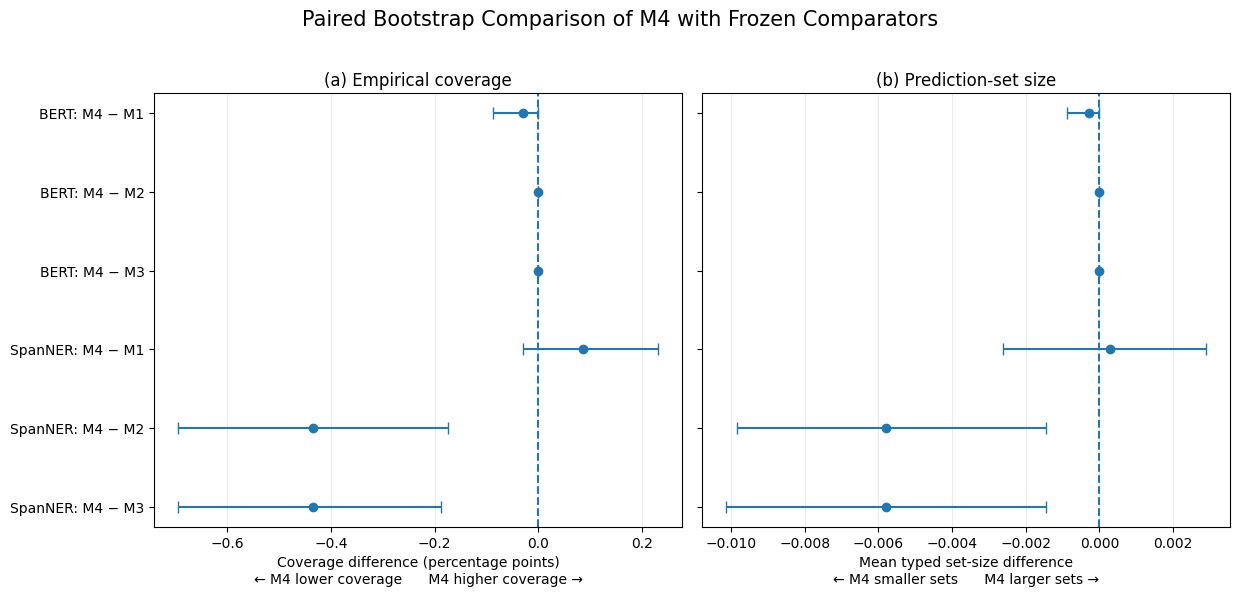

Figure saved: /kaggle/working/08_final_locked_conll_test/figures/paired_bootstrap_M4_vs_comparators.png


In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


FIGURES_OUTPUT_DIR = Path(
    "/kaggle/working/08_final_locked_conll_test/figures"
)

FIGURES_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


bootstrap_plot_df = (
    primary_m4_bootstrap_df
    .copy()
    .reset_index(drop=True)
)

bootstrap_plot_df["Comparison"] = (
    bootstrap_plot_df["Model"]
    + ": M4 − "
    + bootstrap_plot_df["Comparator"]
)

# Convert coverage differences to percentage points.
bootstrap_plot_df["Coverage Difference (pp)"] = (
    bootstrap_plot_df[
        "Coverage Difference"
    ]
    * 100.0
)

bootstrap_plot_df["Coverage CI Lower (pp)"] = (
    bootstrap_plot_df[
        "Coverage CI Lower"
    ]
    * 100.0
)

bootstrap_plot_df["Coverage CI Upper (pp)"] = (
    bootstrap_plot_df[
        "Coverage CI Upper"
    ]
    * 100.0
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5.8),
    sharey=True,
)

y_positions = np.arange(
    len(bootstrap_plot_df)
)[::-1]


# Panel (a): empirical coverage
coverage_values = (
    bootstrap_plot_df[
        "Coverage Difference (pp)"
    ].to_numpy(float)
)

coverage_lower_error = (
    coverage_values
    - bootstrap_plot_df[
        "Coverage CI Lower (pp)"
    ].to_numpy(float)
)

coverage_upper_error = (
    bootstrap_plot_df[
        "Coverage CI Upper (pp)"
    ].to_numpy(float)
    - coverage_values
)

axes[0].errorbar(
    coverage_values,
    y_positions,
    xerr=np.vstack(
        [
            coverage_lower_error,
            coverage_upper_error,
        ]
    ),
    fmt="o",
    capsize=4,
)

axes[0].axvline(
    0.0,
    linestyle="--",
)

axes[0].set_yticks(
    y_positions
)

axes[0].set_yticklabels(
    bootstrap_plot_df[
        "Comparison"
    ]
)

axes[0].set_xlabel(
    "Coverage difference (percentage points)\n"
    "← M4 lower coverage      M4 higher coverage →"
)

axes[0].set_title(
    "(a) Empirical coverage"
)

axes[0].grid(
    alpha=0.25,
    axis="x",
)


# Panel (b): prediction-set size
set_size_values = (
    bootstrap_plot_df[
        "Mean Set-Size Difference"
    ].to_numpy(float)
)

set_size_lower_error = (
    set_size_values
    - bootstrap_plot_df[
        "Set-Size CI Lower"
    ].to_numpy(float)
)

set_size_upper_error = (
    bootstrap_plot_df[
        "Set-Size CI Upper"
    ].to_numpy(float)
    - set_size_values
)

axes[1].errorbar(
    set_size_values,
    y_positions,
    xerr=np.vstack(
        [
            set_size_lower_error,
            set_size_upper_error,
        ]
    ),
    fmt="o",
    capsize=4,
)

axes[1].axvline(
    0.0,
    linestyle="--",
)

axes[1].set_yticks(
    y_positions
)

axes[1].set_yticklabels(
    bootstrap_plot_df[
        "Comparison"
    ]
)

axes[1].set_xlabel(
    "Mean typed set-size difference\n"
    "← M4 smaller sets      M4 larger sets →"
)

axes[1].set_title(
    "(b) Prediction-set size"
)

axes[1].grid(
    alpha=0.25,
    axis="x",
)


figure.suptitle(
    "Paired Bootstrap Comparison of M4 with Frozen Comparators",
    fontsize=15,
    y=1.02,
)

figure.tight_layout()


figure_path = (
    FIGURES_OUTPUT_DIR
    / "paired_bootstrap_M4_vs_comparators.png"
)

figure.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved:",
    figure_path,
)

## 13. BERT Width≤4 Matched-Support Sensitivity

The primary conformal comparison uses each architecture's native candidate support: BERT permits contiguous spans of any sentence-valid width, whereas SpanNER is structurally limited to spans of at most four original words.

To assess how this structural difference affects the final comparison, a secondary sensitivity analysis projects the already-frozen BERT prediction sets onto the same width≤4 positional support used by SpanNER.

This analysis does not refit or recalibrate BERT. The native BERT candidate scores, λ values and q̂ thresholds remain unchanged; candidates wider than four words are removed only at evaluation time.

Accordingly, this is a matched-support sensitivity analysis rather than a newly calibrated width≤4 conformal system. Representable-gold coverage is calculated over gold entities that fall within the width≤4 support, while full-gold coverage additionally requires every original gold entity in the sentence to satisfy the width restriction.

In [18]:
# Restrict the already-scored BERT candidate population to width <= 4.
bert_width4_projection_df = (
    bert_test_conformal_df.loc[
        bert_test_conformal_df[
            "word_length"
        ] <= SPANNER_MAX_WIDTH
    ]
    .copy()
    .reset_index(drop=True)
)


# Confirm that the positional typed support now matches SpanNER.
assert (
    bert_width4_projection_df[
        "word_length"
    ].max()
    == SPANNER_MAX_WIDTH
)

assert len(
    bert_width4_projection_df
) == len(
    spanner_test_conformal_df
)


identity_columns = [
    "sentence_id",
    "start",
    "end",
    "entity_type",
]

bert_width4_identities = (
    bert_width4_projection_df[
        identity_columns
    ]
    .sort_values(
        identity_columns
    )
    .reset_index(drop=True)
)

spanner_identities = (
    spanner_test_conformal_df[
        identity_columns
    ]
    .sort_values(
        identity_columns
    )
    .reset_index(drop=True)
)

assert bert_width4_identities.equals(
    spanner_identities
)


# Under width <= 4 support, a sentence is fully representable
# only when none of its original gold entities exceeds four words.
bert_width4_full_representability = np.ones(
    len(test_records),
    dtype=bool,
)

for row in test_gold_spans_df.itertuples(
    index=False
):
    if (
        int(row.token_count)
        > SPANNER_MAX_WIDTH
    ):
        bert_width4_full_representability[
            int(
                row.sentence_index
            )
        ] = False


# Reuse the already-frozen native BERT scores and q-hats.
(
    bert_width4_sentence_metrics_df,
    bert_width4_primary_gold_df,
) = evaluate_native_conformal_sets(
    candidate_df=(
        bert_width4_projection_df
    ),
    model="BERT",
    fully_representable=(
        bert_width4_full_representability
    ),
)


bert_width4_sentence_metrics_df[
    "Universe"
] = "width_le_4_projection"


bert_width4_sensitivity_summary_df = (
    summarise_sentence_conformal_metrics(
        bert_width4_sentence_metrics_df
    )
)


# Present the matched-support comparison at the primary 90% target.
bert_width4_primary_df = (
    bert_width4_sensitivity_summary_df.loc[
        np.isclose(
            bert_width4_sensitivity_summary_df[
                "Target Coverage"
            ].astype(float),
            PRIMARY_COVERAGE,
        )
    ]
    .reset_index(drop=True)
)


print(
    "Table: BERT WIDTH≤4 MATCHED-SUPPORT SENSITIVITY"
)

display(
    bert_width4_primary_df[
        [
            "Model",
            "Universe",
            "Method",
            "Target Coverage",
            "Empirical Representable-Gold Coverage",
            "Empirical Full-Gold Coverage",
            "Mean Typed Set Size",
            "Mean Extra Typed Candidates",
        ]
    ].round(6)
)

Table: BERT WIDTH≤4 MATCHED-SUPPORT SENSITIVITY


,Model,Universe,Method,Target Coverage,Empirical Representable-Gold Coverage,Empirical Full-Gold Coverage,Mean Typed Set Size,Mean Extra Typed Candidates
0,BERT,width_le_4_projection,M1,0.9,0.848248,0.843325,2.183608,0.746308
1,BERT,width_le_4_projection,M2,0.9,0.847958,0.843035,2.183319,0.746308
2,BERT,width_le_4_projection,M3,0.9,0.847958,0.843035,2.183319,0.746308
3,BERT,width_le_4_projection,M4,0.9,0.847958,0.843035,2.183319,0.746308


## 14. Descriptive Entity-Type and Span-Length Inclusion

The aggregate 90% results do not show whether gold entities with different semantic types or span lengths are retained at similar rates.

As a descriptive subgroup analysis, entity-level inclusion is therefore summarised by entity type and gold span length for each frozen conformal method at the primary 90% operating point.

These results are descriptive only. They are not conditional conformal guarantees and were not used to select λ values, q̂ thresholds or any other model parameter.

For SpanNER, the analysis necessarily includes only structurally representable gold entities of width ≤4 because wider gold spans are absent from its native candidate universe.

In [19]:
# The primary gold-inclusion rows were retained during Section 10.
entity_type_inclusion_df = (
    primary_gold_inclusion_df.groupby(
        [
            "Model",
            "Method",
            "entity_type",
        ],
        as_index=False,
    )
    .agg(
        Gold_Entities=(
            "included",
            "size",
        ),
        Included=(
            "included",
            "sum",
        ),
    )
)

entity_type_inclusion_df[
    "Entity-Level Inclusion"
] = (
    entity_type_inclusion_df[
        "Included"
    ]
    / entity_type_inclusion_df[
        "Gold_Entities"
    ]
)


span_length_inclusion_df = (
    primary_gold_inclusion_df.groupby(
        [
            "Model",
            "Method",
            "word_length",
        ],
        as_index=False,
    )
    .agg(
        Gold_Entities=(
            "included",
            "size",
        ),
        Included=(
            "included",
            "sum",
        ),
    )
)

span_length_inclusion_df[
    "Entity-Level Inclusion"
] = (
    span_length_inclusion_df[
        "Included"
    ]
    / span_length_inclusion_df[
        "Gold_Entities"
    ]
)


print(
    "Table: FINAL TEST PRIMARY 90% ENTITY-TYPE INCLUSION"
)

display(
    entity_type_inclusion_df.round(
        6
    )
)


print(
    "\nTable: FINAL TEST PRIMARY 90% SPAN-LENGTH INCLUSION"
)

display(
    span_length_inclusion_df.round(
        6
    )
)

Table: FINAL TEST PRIMARY 90% ENTITY-TYPE INCLUSION


,Model,Method,entity_type,Gold_Entities,Included,Entity-Level Inclusion
0,BERT,M1,LOC,1668,1509,0.904676
1,BERT,M1,MISC,702,520,0.740741
2,BERT,M1,ORG,1661,1443,0.868754
3,BERT,M1,PER,1617,1511,0.934447
4,BERT,M2,LOC,1668,1509,0.904676
5,BERT,M2,MISC,702,520,0.740741
6,BERT,M2,ORG,1661,1442,0.868152
7,BERT,M2,PER,1617,1511,0.934447
8,BERT,M3,LOC,1668,1509,0.904676
9,BERT,M3,MISC,702,520,0.740741



Table: FINAL TEST PRIMARY 90% SPAN-LENGTH INCLUSION


,Model,Method,word_length,Gold_Entities,Included,Entity-Level Inclusion
0,BERT,M1,1,3574,3121,0.873251
1,BERT,M1,2,1776,1608,0.905405
2,BERT,M1,3,236,201,0.851695
3,BERT,M1,4,37,33,0.891892
4,BERT,M1,5,20,16,0.800000
5,BERT,M1,6,5,4,0.800000
6,BERT,M2,1,3574,3121,0.873251
7,BERT,M2,2,1776,1607,0.904842
8,BERT,M2,3,236,201,0.851695
9,BERT,M2,4,37,33,0.891892


## 15. Calibration → Test Transfer Diagnostics

The conformal thresholds were calibrated on the dedicated conformal-calibration split and then transferred unchanged to the official CoNLL-2003 test set.

The final test results show systematic undercoverage relative to the nominal targets, especially at the primary 90% operating point. This section quantifies that transfer gap without modifying any threshold or model parameter.

For each architecture, method and target level, the empirical coverage achieved on conformal calibration is compared directly with the corresponding locked-test coverage.

The purpose is diagnostic rather than corrective: the analysis assesses how well the frozen calibration behaviour transfers to the final held-out population.

In [20]:
# Calibration coverage was fixed upstream in Notebook 05.
calibration_coverage_lookup = {
    0.90: 0.901538,
    0.95: 0.952308,
    0.99: 0.992308,
}


transfer_rows = []

for row in final_test_conformal_summary_df.itertuples(
    index=False
):
    target = float(
        getattr(
            row,
            "_3",  # Target Coverage
        )
    )

    test_coverage = float(
        getattr(
            row,
            "_5",  # Empirical Representable-Gold Coverage
        )
    )

    calibration_coverage = float(
        calibration_coverage_lookup[
            target
        ]
    )

    transfer_rows.append({
        "Model": getattr(
            row,
            "Model",
        ),
        "Method": getattr(
            row,
            "Method",
        ),
        "Target Coverage": target,
        "Calibration Coverage": (
            calibration_coverage
        ),
        "Test Coverage": (
            test_coverage
        ),
        "Test - Calibration": (
            test_coverage
            - calibration_coverage
        ),
        "Test - Target": (
            test_coverage
            - target
        ),
    })


calibration_to_test_transfer_df = (
    pd.DataFrame(
        transfer_rows
    )
)


print(
    "Table: CALIBRATION → TEST COVERAGE TRANSFER"
)

display(
    calibration_to_test_transfer_df.round(
        6
    )
)

Table: CALIBRATION → TEST COVERAGE TRANSFER


,Model,Method,Target Coverage,Calibration Coverage,Test Coverage,Test - Calibration,Test - Target
0,BERT,M1,0.90,0.901538,0.847379,-0.054159,-0.052621
1,BERT,M1,0.95,0.952308,0.913119,-0.039189,-0.036881
2,BERT,M1,0.99,0.992308,0.971329,-0.020979,-0.018671
3,BERT,M2,0.90,0.901538,0.847089,-0.054449,-0.052911
4,BERT,M2,0.95,0.952308,0.912829,-0.039479,-0.037171
5,BERT,M2,0.99,0.992308,0.974225,-0.018083,-0.015775
6,BERT,M3,0.90,0.901538,0.847089,-0.054449,-0.052911
7,BERT,M3,0.95,0.952308,0.913119,-0.039189,-0.036881
8,BERT,M3,0.99,0.992308,0.971040,-0.021268,-0.018960
9,BERT,M4,0.90,0.901538,0.847089,-0.054449,-0.052911


### 15.1 Visualising Calibration-to-Test Coverage Transfer

The figure below compares the empirical coverage achieved on the conformal-calibration split with the locked-test coverage obtained after transferring the same frozen thresholds.

Points below the calibration reference indicate undercoverage after transfer. The largest deterioration occurs at the primary 90% target, while the gap generally narrows at the higher target levels.

Figure output directory: /kaggle/working/08_final_locked_conll_test/figures


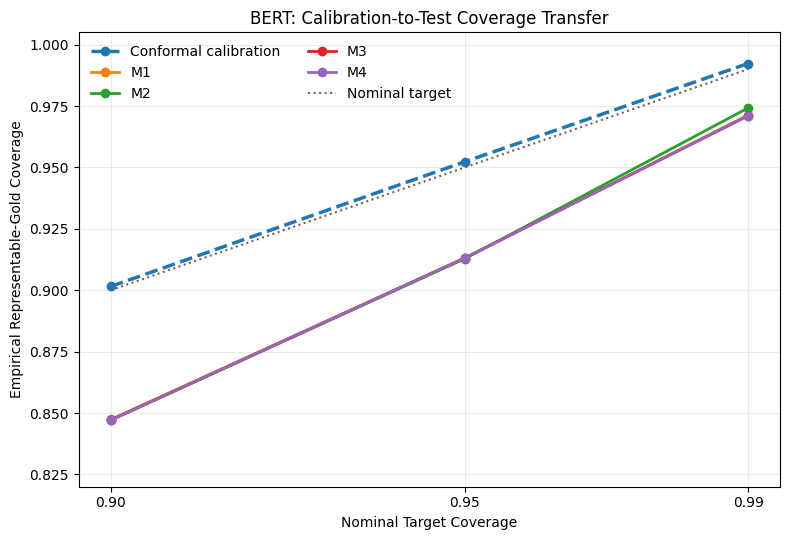

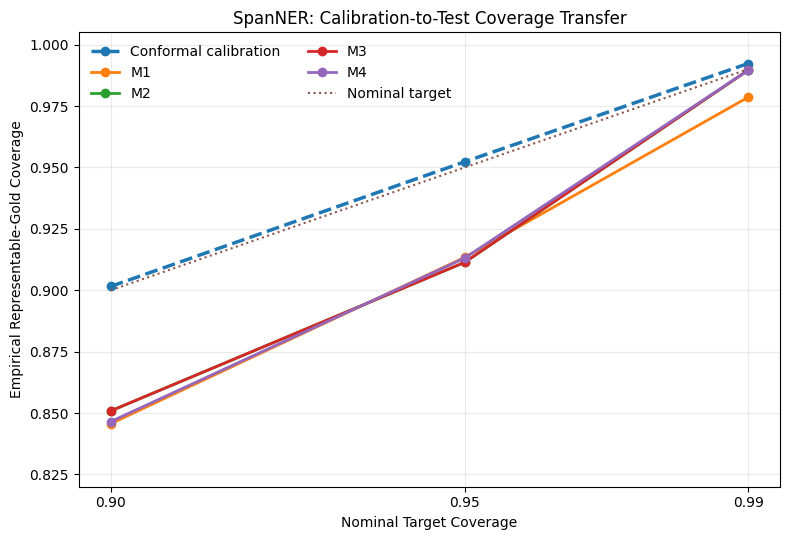

In [21]:
import matplotlib.pyplot as plt

FIGURES_OUTPUT_DIR = Path(
    "/kaggle/working/08_final_locked_conll_test/figures"
)

FIGURES_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Figure output directory:",
    FIGURES_OUTPUT_DIR,
)
# Average only for the calibration reference because calibration
# coverage is identical across M1-M4 at each target.
calibration_reference_df = (
    calibration_to_test_transfer_df[
        [
            "Target Coverage",
            "Calibration Coverage",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "Target Coverage"
    )
)


for model in [
    "BERT",
    "SpanNER",
]:
    figure, axis = plt.subplots(
        figsize=(8, 5.5)
    )

    model_df = (
        calibration_to_test_transfer_df.loc[
            calibration_to_test_transfer_df[
                "Model"
            ] == model
        ]
    )

    # Frozen conformal-calibration reference.
    axis.plot(
        calibration_reference_df[
            "Target Coverage"
        ],
        calibration_reference_df[
            "Calibration Coverage"
        ],
        marker="o",
        linewidth=2.5,
        linestyle="--",
        label="Conformal calibration",
    )

    # Locked-test transfer for each frozen method.
    for method in METHODS:
        method_df = (
            model_df.loc[
                model_df[
                    "Method"
                ] == method
            ]
            .sort_values(
                "Target Coverage"
            )
        )

        axis.plot(
            method_df[
                "Target Coverage"
            ],
            method_df[
                "Test Coverage"
            ],
            marker="o",
            linewidth=2,
            label=method,
        )

    # Nominal target reference.
    axis.plot(
        TARGET_COVERAGES,
        TARGET_COVERAGES,
        linewidth=1.5,
        linestyle=":",
        label="Nominal target",
    )

    axis.set_xlabel(
        "Nominal Target Coverage"
    )

    axis.set_ylabel(
        "Empirical Representable-Gold Coverage"
    )

    axis.set_title(
        f"{model}: Calibration-to-Test Coverage Transfer"
    )

    axis.set_xticks(
        TARGET_COVERAGES
    )

    axis.set_ylim(
        0.82,
        1.005,
    )

    axis.grid(
        alpha=0.25
    )

    axis.legend(
        frameon=False,
        ncol=2,
    )

    figure.tight_layout()

    figure.savefig(
        FIGURES_OUTPUT_DIR
        / (
            f"{model.lower()}_"
            "calibration_to_test_coverage_transfer.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

## 16. Final-Test Coverage–Efficiency Visualisation

Coverage alone does not determine whether a conformal method is useful; the corresponding prediction-set size must also be considered.

The final coverage–efficiency plots therefore position each frozen M1–M4 operating point according to its empirical representable-gold coverage and mean typed prediction-set size at the 90%, 95% and 99% target levels.

The architectures are shown separately because their native candidate universes differ substantially in size. The plots are descriptive and use the already-computed locked-test results without any further calibration or parameter selection.

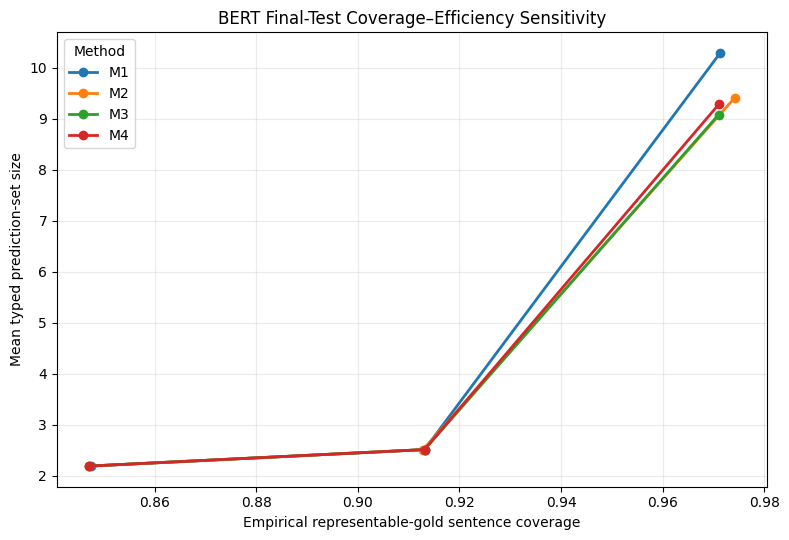

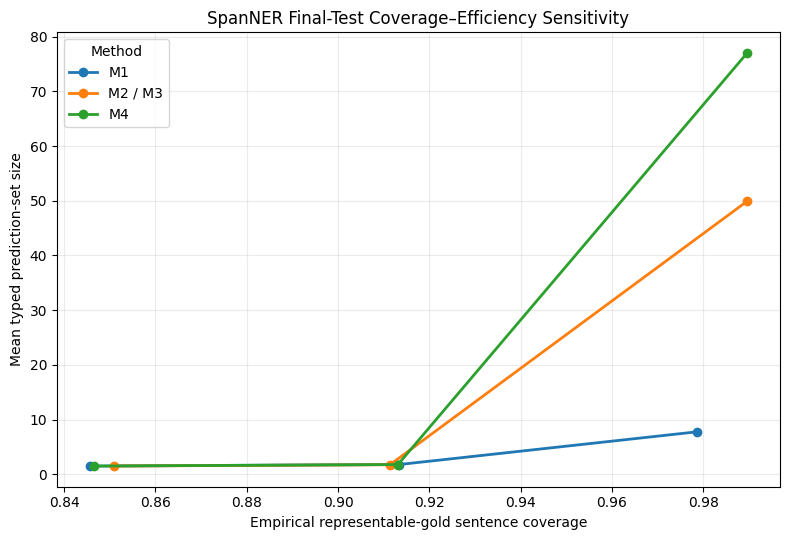

In [22]:
# BERT final-test coverage-efficiency sensitivity
figure, axis = plt.subplots(
    figsize=(8, 5.5)
)

bert_plot_df = (
    final_test_conformal_summary_df.loc[
        final_test_conformal_summary_df[
            "Model"
        ] == "BERT"
    ]
    .copy()
)

for method in [
    "M1",
    "M2",
    "M3",
    "M4",
]:
    method_df = (
        bert_plot_df.loc[
            bert_plot_df[
                "Method"
            ] == method
        ]
        .sort_values(
            "Target Coverage"
        )
    )

    axis.plot(
        method_df[
            "Empirical Representable-Gold Coverage"
        ],
        method_df[
            "Mean Typed Set Size"
        ],
        marker="o",
        linewidth=2,
        label=method,
    )

axis.set_xlabel(
    "Empirical representable-gold sentence coverage"
)

axis.set_ylabel(
    "Mean typed prediction-set size"
)

axis.set_title(
    "BERT Final-Test Coverage–Efficiency Sensitivity"
)

axis.grid(
    alpha=0.25
)

axis.legend(
    title="Method",
    frameon=True,
)

figure.tight_layout()

figure.savefig(
    FIGURES_OUTPUT_DIR
    / "bert_final_test_coverage_efficiency_sensitivity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# SpanNER final-test coverage-efficiency sensitivity
figure, axis = plt.subplots(
    figsize=(8, 5.5)
)

spanner_plot_df = (
    final_test_conformal_summary_df.loc[
        final_test_conformal_summary_df[
            "Model"
        ] == "SpanNER"
    ]
    .copy()
)


# M1
m1_df = (
    spanner_plot_df.loc[
        spanner_plot_df[
            "Method"
        ] == "M1"
    ]
    .sort_values(
        "Target Coverage"
    )
)

axis.plot(
    m1_df[
        "Empirical Representable-Gold Coverage"
    ],
    m1_df[
        "Mean Typed Set Size"
    ],
    marker="o",
    linewidth=2,
    label="M1",
)


# M2 and M3 are identical under the frozen SpanNER configuration.
m2_df = (
    spanner_plot_df.loc[
        spanner_plot_df[
            "Method"
        ] == "M2"
    ]
    .sort_values(
        "Target Coverage"
    )
)

axis.plot(
    m2_df[
        "Empirical Representable-Gold Coverage"
    ],
    m2_df[
        "Mean Typed Set Size"
    ],
    marker="o",
    linewidth=2,
    label="M2 / M3",
)


# M4
m4_df = (
    spanner_plot_df.loc[
        spanner_plot_df[
            "Method"
        ] == "M4"
    ]
    .sort_values(
        "Target Coverage"
    )
)

axis.plot(
    m4_df[
        "Empirical Representable-Gold Coverage"
    ],
    m4_df[
        "Mean Typed Set Size"
    ],
    marker="o",
    linewidth=2,
    label="M4",
)

axis.set_xlabel(
    "Empirical representable-gold sentence coverage"
)

axis.set_ylabel(
    "Mean typed prediction-set size"
)

axis.set_title(
    "SpanNER Final-Test Coverage–Efficiency Sensitivity"
)

axis.grid(
    alpha=0.25
)

axis.legend(
    title="Method",
    frameon=True,
)

figure.tight_layout()

figure.savefig(
    FIGURES_OUTPUT_DIR
    / "spanner_final_test_coverage_efficiency_sensitivity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 17. Post-Hoc Gold Nonconformity Shift

The locked-test analysis showed substantial calibration-to-test movement in the upper tail of the sentence-level gold nonconformity distribution. As a compact post-hoc diagnostic, the figure below compares the descriptive 90th percentile of the sentence-level M1 gold nonconformity scores between the conformal-calibration and official-test populations. For BERT, the 90th percentile increased from approximately 0.116 to 0.612. For SpanNER, it increased from approximately 0.146 to 0.632. The dashed lines show the corresponding frozen 90% M1 conformal thresholds. This diagnostic is descriptive only and is not used to modify q̂, λ, model parameters or any final-test result.

BERT calibration components: /kaggle/input/datasets/umrahzargar/05-conformal-new/05_conformal_prediction_M1_M4/downstream/bert_conformal_calibration_components.parquet
SpanNER calibration components: /kaggle/input/datasets/umrahzargar/05-conformal-new/05_conformal_prediction_M1_M4/downstream/spanner_conformal_calibration_components.parquet

Table: Calibration-to-Test Sentence-Level Gold Nonconformity Shift


,Model,Population,P90 Gold Nonconformity,Frozen q_hat
0,BERT,Conformal\ncalibration,0.115979,0.117814
1,BERT,Official\ntest,0.611892,0.117814
2,SpanNER,Conformal\ncalibration,0.145563,0.149860
3,SpanNER,Official\ntest,0.631865,0.149860



BERT calibration sentence-level P90: 0.115979433
BERT test sentence-level P90: 0.611892413
BERT frozen M1 q_hat: 0.117814256

SpanNER calibration sentence-level P90: 0.145563092
SpanNER test sentence-level P90: 0.631865382
SpanNER frozen M1 q_hat: 0.149860071


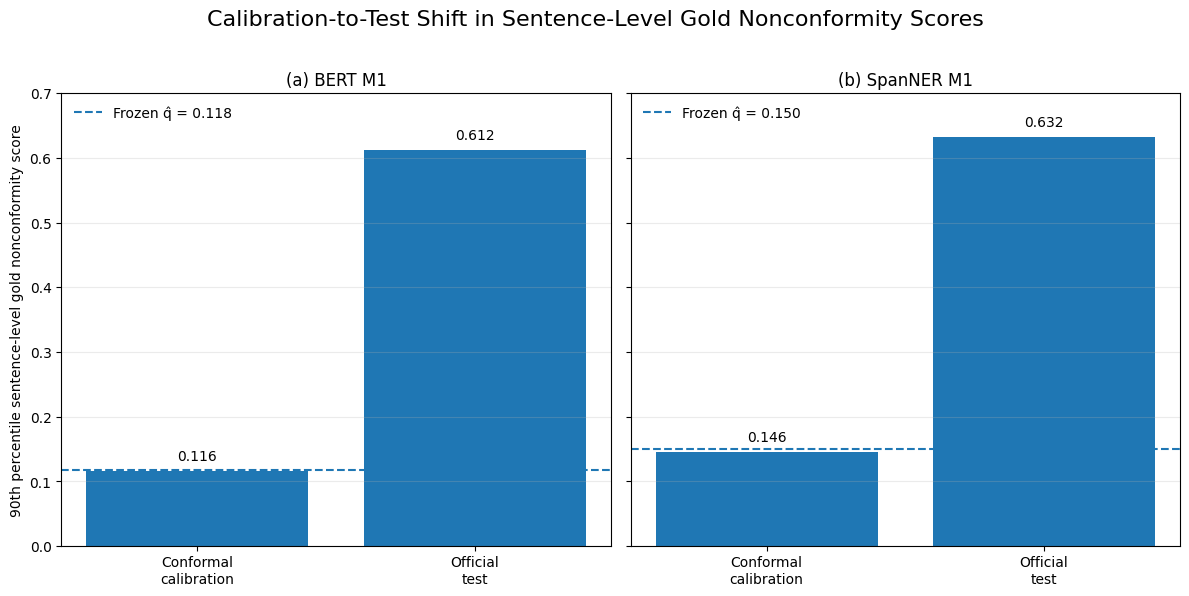

Figure saved: /kaggle/working/08_final_locked_conll_test/figures/calibration_to_test_gold_nonconformity_shift.png


In [23]:
# Calibration-to-test shift in M1 gold nonconformity
# Recomputed entirely from current frozen artefacts
#
# IMPORTANT:
# The conformal unit in this dissertation is the SENTENCE.
# Therefore the diagnostic below first takes, for each sentence,
# the maximum M1 nonconformity among its representable gold
# typed-span candidates. Sentences with no representable gold
# candidate receive score 0, matching the conformal methodology.
# The reported P90 is then a descriptive 90th percentile of
# these sentence-level scores.


# 1. Resolve Notebook-05 calibration component tables
#    from the SAME Notebook-05 root already audited above

NOTEBOOK05_ROOT = CONFORMAL_SPEC_PATH.parents[1]


def find_unique_notebook05_file(
    filename,
):
    matches = list(
        NOTEBOOK05_ROOT.rglob(
            filename
        )
    )

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected exactly one {filename} "
            f"under {NOTEBOOK05_ROOT}, "
            f"but found {len(matches)}:\n"
            + "\n".join(
                str(path)
                for path in matches
            )
        )

    return matches[0]


bert_calibration_components_path = (
    find_unique_notebook05_file(
        "bert_conformal_calibration_components.parquet"
    )
)

spanner_calibration_components_path = (
    find_unique_notebook05_file(
        "spanner_conformal_calibration_components.parquet"
    )
)


bert_calibration_components_df = (
    pd.read_parquet(
        bert_calibration_components_path
    )
)

spanner_calibration_components_df = (
    pd.read_parquet(
        spanner_calibration_components_path
    )
)


print(
    "BERT calibration components:",
    bert_calibration_components_path,
)

print(
    "SpanNER calibration components:",
    spanner_calibration_components_path,
)


# 2. Helper: robust gold-candidate mask

def gold_candidate_mask(
    dataframe,
):
    values = dataframe[
        "is_gold_candidate"
    ]

    if pd.api.types.is_bool_dtype(
        values
    ):
        return values.fillna(False)

    return (
        values
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(
            [
                "true",
                "1",
            ]
        )
    )


# 3. Helper: sentence-level M1 gold nonconformity

def sentence_level_gold_m1_scores(
    candidate_df,
):
    """
    Construct sentence-level M1 calibration/evaluation scores.

    For each sentence:
      score = maximum base_nonconformity among representable
              gold typed-span candidates.

    Sentences containing no representable gold candidate
    receive score 0.0, matching the dissertation's
    sentence-level conformal definition.
    """

    required_columns = {
        "sentence_id",
        "is_gold_candidate",
        "base_nonconformity",
    }

    missing_columns = (
        required_columns
        - set(candidate_df.columns)
    )

    if missing_columns:
        raise RuntimeError(
            "Candidate table is missing required columns: "
            + ", ".join(
                sorted(
                    missing_columns
                )
            )
        )


    working_df = candidate_df[
        [
            "sentence_id",
            "is_gold_candidate",
            "base_nonconformity",
        ]
    ].copy()


    # Normalise sentence identifiers
    working_df[
        "sentence_id"
    ] = pd.to_numeric(
        working_df[
            "sentence_id"
        ],
        errors="raise",
    ).astype(int)


    # All sentences represented in the candidate table
    all_sentence_ids = np.sort(
        working_df[
            "sentence_id"
        ]
        .unique()
    )


    if len(all_sentence_ids) == 0:
        raise RuntimeError(
            "Candidate table contains no sentences."
        )


    # Retain representable gold typed-span candidates
    gold_mask = gold_candidate_mask(
        working_df
    )

    gold_rows = working_df.loc[
        gold_mask,
        [
            "sentence_id",
            "base_nonconformity",
        ],
    ].copy()


    gold_rows[
        "base_nonconformity"
    ] = pd.to_numeric(
        gold_rows[
            "base_nonconformity"
        ],
        errors="coerce",
    )


    gold_rows = gold_rows.dropna(
        subset=[
            "base_nonconformity",
        ]
    )


    # Maximum representable-gold nonconformity per sentence
    sentence_scores = (
        gold_rows
        .groupby(
            "sentence_id"
        )[
            "base_nonconformity"
        ]
        .max()
    )


    # Reintroduce sentences with no representable gold span.
    # Their conformal sentence score is defined as zero.
    sentence_scores = (
        sentence_scores
        .reindex(
            all_sentence_ids,
            fill_value=0.0,
        )
        .astype(float)
    )


    if sentence_scores.isna().any():
        raise RuntimeError(
            "Sentence-level gold nonconformity "
            "contains NaN values."
        )


    return sentence_scores


# 4. Helper: descriptive P90 of sentence-level scores

def gold_m1_p90(
    candidate_df,
):
    sentence_scores = (
        sentence_level_gold_m1_scores(
            candidate_df
        )
    )

    return float(
        np.quantile(
            sentence_scores.to_numpy(
                dtype=float
            ),
            0.90,
            method="linear",
        )
    )


# 
# 5. Use the already-defined authoritative q-hat reader
#    from Notebook 08

bert_m1_q90 = get_frozen_q_hat(
    model="BERT",
    method="M1",
    target_coverage=0.90,
)

spanner_m1_q90 = get_frozen_q_hat(
    model="SpanNER",
    method="M1",
    target_coverage=0.90,
)


# 6. Recompute sentence-level calibration/test P90 values

bert_calibration_sentence_scores = (
    sentence_level_gold_m1_scores(
        bert_calibration_components_df
    )
)

bert_test_sentence_scores = (
    sentence_level_gold_m1_scores(
        bert_test_conformal_df
    )
)

spanner_calibration_sentence_scores = (
    sentence_level_gold_m1_scores(
        spanner_calibration_components_df
    )
)

spanner_test_sentence_scores = (
    sentence_level_gold_m1_scores(
        spanner_test_conformal_df
    )
)


bert_calibration_p90 = float(
    np.quantile(
        bert_calibration_sentence_scores,
        0.90,
        method="linear",
    )
)

bert_test_p90 = float(
    np.quantile(
        bert_test_sentence_scores,
        0.90,
        method="linear",
    )
)

spanner_calibration_p90 = float(
    np.quantile(
        spanner_calibration_sentence_scores,
        0.90,
        method="linear",
    )
)

spanner_test_p90 = float(
    np.quantile(
        spanner_test_sentence_scores,
        0.90,
        method="linear",
    )
)


# Sanity checks on expected CoNLL populations

assert (
    len(
        bert_calibration_sentence_scores
    )
    == 650
), (
    "Unexpected BERT conformal-calibration "
    "sentence count."
)

assert (
    len(
        spanner_calibration_sentence_scores
    )
    == 650
), (
    "Unexpected SpanNER conformal-calibration "
    "sentence count."
)

assert (
    len(
        bert_test_sentence_scores
    )
    == 3453
), (
    "Unexpected BERT official-test "
    "sentence count."
)

assert (
    len(
        spanner_test_sentence_scores
    )
    == 3453
), (
    "Unexpected SpanNER official-test "
    "sentence count."
)


# 7. Build diagnostic table

gold_nonconformity_shift_df = pd.DataFrame(
    [
        {
            "Model": "BERT",
            "Population": (
                "Conformal\ncalibration"
            ),
            "P90 Gold Nonconformity": (
                bert_calibration_p90
            ),
            "Frozen q_hat": (
                bert_m1_q90
            ),
        },
        {
            "Model": "BERT",
            "Population": (
                "Official\ntest"
            ),
            "P90 Gold Nonconformity": (
                bert_test_p90
            ),
            "Frozen q_hat": (
                bert_m1_q90
            ),
        },
        {
            "Model": "SpanNER",
            "Population": (
                "Conformal\ncalibration"
            ),
            "P90 Gold Nonconformity": (
                spanner_calibration_p90
            ),
            "Frozen q_hat": (
                spanner_m1_q90
            ),
        },
        {
            "Model": "SpanNER",
            "Population": (
                "Official\ntest"
            ),
            "P90 Gold Nonconformity": (
                spanner_test_p90
            ),
            "Frozen q_hat": (
                spanner_m1_q90
            ),
        },
    ]
)


print(
    "\nTable: Calibration-to-Test "
    "Sentence-Level Gold Nonconformity Shift"
)

display(
    gold_nonconformity_shift_df.round(
        6
    )
)


print(
    "\nBERT calibration sentence-level P90:",
    f"{bert_calibration_p90:.9f}",
)

print(
    "BERT test sentence-level P90:",
    f"{bert_test_p90:.9f}",
)

print(
    "BERT frozen M1 q_hat:",
    f"{bert_m1_q90:.9f}",
)


print(
    "\nSpanNER calibration sentence-level P90:",
    f"{spanner_calibration_p90:.9f}",
)

print(
    "SpanNER test sentence-level P90:",
    f"{spanner_test_p90:.9f}",
)

print(
    "SpanNER frozen M1 q_hat:",
    f"{spanner_m1_q90:.9f}",
)


# 8. Plot

figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.8),
    sharey=True,
)


for axis, model, panel_title in [
    (
        axes[0],
        "BERT",
        "(a) BERT M1",
    ),
    (
        axes[1],
        "SpanNER",
        "(b) SpanNER M1",
    ),
]:

    model_df = (
        gold_nonconformity_shift_df.loc[
            gold_nonconformity_shift_df[
                "Model"
            ] == model
        ]
        .reset_index(
            drop=True
        )
    )


    axis.bar(
        model_df[
            "Population"
        ],
        model_df[
            "P90 Gold Nonconformity"
        ],
    )


    q_hat = float(
        model_df[
            "Frozen q_hat"
        ].iloc[0]
    )


    axis.axhline(
        q_hat,
        linestyle="--",
        label=(
            f"Frozen q̂ = "
            f"{q_hat:.3f}"
        ),
    )


    for row_index, row in (
        model_df.iterrows()
    ):

        value = float(
            row[
                "P90 Gold Nonconformity"
            ]
        )

        axis.text(
            row_index,
            value + 0.012,
            f"{value:.3f}",
            ha="center",
            va="bottom",
        )


    axis.set_title(
        panel_title
    )

    axis.set_ylim(
        0.0,
        0.70,
    )

    axis.grid(
        alpha=0.25,
        axis="y",
    )

    axis.legend(
        frameon=False,
        loc="upper left",
    )


axes[0].set_ylabel(
    "90th percentile sentence-level "
    "gold nonconformity score"
)


figure.suptitle(
    "Calibration-to-Test Shift in "
    "Sentence-Level Gold Nonconformity Scores",
    fontsize=16,
    y=1.02,
)

figure.tight_layout()


gold_shift_figure_path = (
    FIGURES_OUTPUT_DIR
    / (
        "calibration_to_test_"
        "gold_nonconformity_shift.png"
    )
)


figure.savefig(
    gold_shift_figure_path,
    dpi=300,
    bbox_inches="tight",
)


plt.show()


print(
    "Figure saved:",
    gold_shift_figure_path,
)

## 18. Final Artefacts and Evaluation Freeze

The locked CoNLL-2003 evaluation is now complete.

All reported results were obtained using the frozen models, probability-calibration parameters, conformal λ configurations and q̂ thresholds established before final-test evaluation. No model retraining, temperature refitting, λ retuning, q̂ recalibration or new method development was performed in response to the official test results.

The final tables, downstream diagnostic records and figures are saved below to provide a reproducible handoff for dissertation reporting and external replication.

After this point, Notebook 08 is treated as frozen.

In [24]:
FINAL_OUTPUT_ROOT = Path(
    "/kaggle/working/08_final_locked_conll_test"
)

FINAL_RESULTS_DIR = (
    FINAL_OUTPUT_ROOT
    / "results"
)

FINAL_DOWNSTREAM_DIR = (
    FINAL_OUTPUT_ROOT
    / "downstream"
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FINAL_DOWNSTREAM_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Save deterministic NER results.
final_ner_results_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_test_deterministic_ner_results.csv",
    index=False,
)

final_per_type_results_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_test_per_type_ner_results.csv",
    index=False,
)


# Save conformal candidate-support summary.
candidate_support_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_test_conformal_candidate_support.csv",
    index=False,
)


# Save primary 90% conformal results.
primary_90_final_test_df.to_csv(
    FINAL_RESULTS_DIR
    / "primary_90_final_test_results.csv",
    index=False,
)


# Save direct M4 comparisons.
primary_m4_comparison_df.to_csv(
    FINAL_RESULTS_DIR
    / "primary_90_M4_comparison.csv",
    index=False,
)

primary_m4_bootstrap_df.to_csv(
    FINAL_RESULTS_DIR
    / "primary_90_M4_paired_bootstrap.csv",
    index=False,
)


# Save the complete 90/95/99 ladder.
final_test_conformal_summary_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_test_conformal_coverage_efficiency.csv",
    index=False,
)


# Save matched-support sensitivity.
bert_width4_sensitivity_summary_df.to_csv(
    FINAL_RESULTS_DIR
    / "bert_width4_matched_support_sensitivity.csv",
    index=False,
)


# Save descriptive subgroup diagnostics.
entity_type_inclusion_df.to_csv(
    FINAL_RESULTS_DIR
    / "primary_90_entity_type_inclusion.csv",
    index=False,
)

span_length_inclusion_df.to_csv(
    FINAL_RESULTS_DIR
    / "primary_90_span_length_inclusion.csv",
    index=False,
)


# Save calibration-to-test transfer diagnostics.
calibration_to_test_transfer_df.to_csv(
    FINAL_RESULTS_DIR
    / "calibration_to_test_coverage_transfer.csv",
    index=False,
)

gold_nonconformity_shift_df.to_csv(
    FINAL_RESULTS_DIR
    / "posthoc_gold_nonconformity_shift.csv",
    index=False,
)


# Preserve sentence-level evaluation records for downstream analysis.
native_sentence_metrics_df.to_parquet(
    FINAL_DOWNSTREAM_DIR
    / "native_test_sentence_conformal_metrics.parquet",
    index=False,
)

primary_gold_inclusion_df.to_parquet(
    FINAL_DOWNSTREAM_DIR
    / "primary_90_gold_entity_inclusion.parquet",
    index=False,
)

bert_width4_sentence_metrics_df.to_parquet(
    FINAL_DOWNSTREAM_DIR
    / "bert_width4_test_sentence_metrics.parquet",
    index=False,
)


# Candidate-level component tables were already created in Section 9.
# Save the final scored versions as well.
bert_test_conformal_df.to_parquet(
    FINAL_DOWNSTREAM_DIR
    / "bert_test_conformal_components_scored.parquet",
    index=False,
)

spanner_test_conformal_df.to_parquet(
    FINAL_DOWNSTREAM_DIR
    / "spanner_test_conformal_components_scored.parquet",
    index=False,
)


# Record the final one-shot evaluation state.
completion_record = {
    "notebook": (
        "08_final_locked_conll_test"
    ),
    "official_test_accessed": bool(
        OFFICIAL_TEST_ACCESSED
    ),
    "official_test_sentences": int(
        len(test_records)
    ),
    "official_test_gold_entities": int(
        len(test_gold_spans_df)
    ),
    "bert_test_f1": float(
        bert_test_metrics[
            "F1"
        ]
    ),
    "spanner_test_f1": float(
        spanner_test_metrics[
            "F1"
        ]
    ),
    "models_retrained": bool(
        MODELS_RETRAINED
    ),
    "temperatures_refitted": bool(
        TEMPERATURES_REFITTED
    ),
    "lambdas_retuned": bool(
        LAMBDAS_RETUNED
    ),
    "q_hats_recalibrated": bool(
        Q_HATS_RECALIBRATED
    ),
    "method_development_performed": bool(
        METHOD_DEVELOPMENT_PERFORMED
    ),
    "primary_target_coverage": float(
        PRIMARY_COVERAGE
    ),
    "target_coverages": [
        float(value)
        for value in TARGET_COVERAGES
    ],
    "primary_methods": list(
        METHODS
    ),
    "final_test_frozen": True,
}


with open(
    FINAL_OUTPUT_ROOT
    / "completion_record.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        completion_record,
        file,
        indent=2,
    )


print(
    "Final Notebook-08 artefacts saved to:"
)

print(
    FINAL_OUTPUT_ROOT
)

print(
    "\nCompletion record:"
)

display(
    pd.DataFrame(
        [
            completion_record
        ]
    )
)

print(
    "\nNotebook 08 final evaluation freeze: COMPLETE"
)

Final Notebook-08 artefacts saved to:
/kaggle/working/08_final_locked_conll_test

Completion record:


,notebook,official_test_accessed,official_test_sentences,official_test_gold_entities,bert_test_f1,spanner_test_f1,models_retrained,temperatures_refitted,lambdas_retuned,q_hats_recalibrated,method_development_performed,primary_target_coverage,target_coverages,primary_methods,final_test_frozen
0,08_final_locked_conll_test,True,3453,5648,0.91024,0.915846,False,False,False,False,False,0.9,"[0.9, 0.95, 0.99]","[M1, M2, M3, M4]",True



Notebook 08 final evaluation freeze: COMPLETE
